# Customer Lifetime Value (CLV) Prediction on Car Insurance

## Business Problem Understanding

**Context**

Car insurance is a type of financial protection that helps cover the cost of damage or loss related to a vehicle. Customers pay a monthly or annual fee (called a premium) to an insurance company, and in return, the company agrees to help pay for certain types of damage or accidents. Car insurance is not only a service—it’s also a business. Like any business, it aims to stay profitable while delivering value to its customers. 

Customer Lifetime Value (CLV) is one of the metrics that estimates how much revenue a business can expect from a customer over the entire period of their relationship. Instead of looking at just one transaction, CLV helps businesses understand the long-term value of keeping a customer. For example, someone who stays with the same insurance company for many years and buys multiple insurance products is worth more than someone who only buys one product for a short time.

In the car insurance industry, not all customers contribute the same amount of value. Some may leave quickly, while others stay for years and buy multiple policies. Some may applied for many claims that reduce the profit that the customer contribute to the company. So, predicting CLV helps insurance companies to target the right customers by knowing which customers are likely to bring more value over time, so the company can focus its marketing and sales efforts more effectively. Predicting CLV also helps companies to accept or reject any applicant. This also help company to design better offers to customers with higher potential value like loyalty rewards, discounts, or personalized products to keep them engaged. Predicting CLV also help to manage resources efficiently allocate budgets more wisely between acquiring new customers and retaining existing ones.

**Problem Statement**

As a data scientist, I was tasked with developing a machine learning model to predict Customer Lifetime Value (CLV) based on basic customer information. By estimating the future value of each customer, the company can more effectively identify high-value individuals at the early stage—helping them decide which new customer segments to target and which applications to prioritize. In addition, these insights support better marketing strategies for retaining existing customers and maximizing their long-term value.

**Goal**

- Predict Customer Lifetime Value (CLV): Develop a machine learning regression model to estimate each customer’s projected lifetime value based on their profile
- Understand Key Drivers of CLV: Analyze feature importance and behavioral patterns to identify the most influential factors that contribute to high or low CLV.
- Support Strategic Decision-Making: Provide data-driven recommendations to inform customer acquisition targeting and personalized retention strategies that maximize long-term customer value.

**Analytical Approach**

In this project, we aim to develop a regression-based machine learning model to predict Customer Lifetime Value (CLV). The analytical process is structured into the following key stages:
- Data Understanding: We begin by exploring the dataset to understand its structure, identify key variables, assess data quality, and clean up the dataset.
- Exploratory Data Analysis (EDA): We conduct EDA to uncover patterns and relationships between predictor variables and CLV. This step helps guide feature selection and provides early business insights.
- Data Preparation: Based on the insights from the exploration, we perform necessary preprocessing steps such as handling missing values, encoding categorical variables, scaling numerical features, and removing irrelevant or redundant columns to prepare the data for modeling.
- Model Building and Evaluation: We build and evaluate several regression models to identify the most effective one for predicting CLV. The model selection is based on evaluation metrics such as Root Mean Squared Error (RMSE) and R-squared, using a train-test split to assess performance.
- Model Interpretation: Once the model is finalized, we use feature importance techniques (e.g., SHAP values) to interpret the key drivers of CLV. These insights are then combined with findings from the EDA to generate actionable recommendations for customer acquisition and retention strategies.

**Metric Evaluation**

To assess the performance of the regression model in predicting Customer Lifetime Value (CLV), we use several key metrics:
- Root Mean Squared Error (RMSE): Measures the average magnitude of prediction errors, giving higher weight to large errors. Lower RMSE indicates better model accuracy.
- Mean Absolute Error (MAE): Represents the average absolute difference between predicted and actual values. It provides a straightforward interpretation of the typical error size.
- Mean Absolute Percentage Error (MAPE): Shows the prediction error as a percentage of actual values, helping us understand the error relative to the true CLV.
- R-squared (R²): Indicates how well the model explains the variance in CLV. A higher R² value means the model captures more of the underlying patterns.

These metrics help us ensure that the model not only fits the training data well but also makes accurate and meaningful predictions for future or unseen data. In selecting the best model, we aim for the lowest RMSE, MAE, and MAPE, while maximizing the R-squared value.


## Data Understanding

**Attribute Informations**
- Vehicle Class: The type or category of the customer’s vehicle (e.g., Four-Door Car, SUV, Sports Car, Two-Door Car, Luxury SUV, Luxury Car)
- Coverage: The level of insurance coverage chosen by the customer (e.g., basic, extended, premium)
- Renew Offer Type: The type of renewal offer presented to the customer when renewing their policy
- Employment Status: The current employment condition of the customer (e.g., employed, unemployed, retired, disabled, medical leave)
- Marital Status: The marital status of the customer (e.g., single, married, divorced)
- Education: The highest level of formal education attained by the customer
- Number of Policies: The total number of insurance policies the customer holds
- Monthly Premium Auto: The amount the customer pays monthly for their auto insurance policy
- Total Claim Amount: The total monetary value of all insurance claims the customer has submitted
- Income: The customer’s total annual income
- Customer Lifetime Value (CLV): The estimated profit the company expects to earn from the customer over the entire duration of their relationship

**Import Libraries**

In [1]:
#Basic data libraries
import pandas as pd
import numpy as np

#Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import shap

#Statistical analysis
import statsmodels.api as sm
from scipy.stats import kruskal

#Features engineering
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelBinarizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import category_encoders as ce
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

#Feature selection
from sklearn.feature_selection import SelectKBest, SelectPercentile, f_regression, mutual_info_regression
from sklearn.decomposition import PCA

#Data preprocessing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import TransformedTargetRegressor

#Model selection
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor, plot_importance


#Model evaluation and hyperparameter tuning
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error, mean_squared_error
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV
from sklearn.dummy import DummyRegressor

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

#Saving models
import pickle

In [2]:
# Dataset loading
data = pd.read_csv('data_customer_lifetime_value.csv')
data.head()

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2.0,90.0,571.479602,11828.0,10083.486880
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6.0,62.0,114.514440,44762.0,4943.386117
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2.0,62.0,257.248789,21514.0,11981.984810
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1.0,116.0,556.800000,17913.0,4550.856045
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1.0,62.0,355.820799,19030.0,2372.155492


In [3]:
# Checking the shape of the dataset
print(f'This dataset contains {data.shape[0]} rows and {data.shape[1]} columns.')

This dataset contains 5669 rows and 11 columns.


In [4]:
# Duplicated rows check
duplicated = data.duplicated()

if duplicated.sum() > 0:
    print(f'Approximately, {round(duplicated.sum()/data.shape[0]*100, 2)}% or about {duplicated.sum()} rows are duplicated row.')
else:
    print('This dataset does not contain any duplicated rows.')

Approximately, 10.9% or about 618 rows are duplicated row.


Observations:
- This dataset contains 618 rows or 10.9% rows as duplicated data, but we couldn't fully sure that this is duplicated data because there are no unique customer identifier
- But, these duplicates across both features and target variables. Since they introduce redundancy and potential bias, we need to drop this even though we realize that this duplicated data is quite big. But, keeping them will not help us anyway because it doesn't give any new pattern or new information.

In [5]:
# Drop duplicated rows
data = data.drop_duplicates()
print(f'This dataset contains {data.shape[0]} rows and {data.shape[1]} columns after removing duplicated rows.')

This dataset contains 5051 rows and 11 columns after removing duplicated rows.


In [6]:
# Check for datatypes, missing values, number of unique values, and a sample of unique values
listItem = []

for col in data.columns:
    listItem.append([col, data[col].dtype, data[col].isnull().sum(), data[col].nunique(), data[col].unique()[:3]])

data_desc = pd.DataFrame(listItem, columns=['Features', 'Data Type', 'Missing', 'Unique', 'Unique Values Sample'])

data_desc

,Features,Data Type,Missing,Unique,Unique Values Sample
0,Vehicle Class,object,0,6,"[Four-Door Car, Two-Door Car, SUV]"
1,Coverage,object,0,3,"[Extended, Basic, Premium]"
2,Renew Offer Type,object,0,4,"[Offer1, Offer3, Offer2]"
3,EmploymentStatus,object,0,5,"[Retired, Employed, Disabled]"
4,Marital Status,object,0,3,"[Divorced, Married, Single]"
5,Education,object,0,5,"[High School or Below, College, Master]"
6,Number of Policies,float64,0,9,"[2.0, 6.0, 1.0]"
7,Monthly Premium Auto,float64,0,191,"[90.0, 62.0, 116.0]"
8,Total Claim Amount,float64,0,3274,"[571.479602, 114.51444, 257.248789]"
9,Income,float64,0,3625,"[11828.0, 44762.0, 21514.0]"


Observations: 
- Vehicle Class, Coverage, Renew Offer Type, Employment Status, Marital Status, and Education are identified as categorical due to their object data type and low number of unique values. Since each has a manageable number of categories (≤6), they have low cardinality and can be encoded using label encoding or one-hot encoding depending on the model, but binary transformation (e.g., one-vs-rest) is not necessary at this dataset.
- Number of Policies, Monthly Premium Auto, Total Claim Amount, Income, and Customer Lifetime Value are numerical, stored as float64.
- Since Number of Policies has only 9 unique values, we will analyze it as a categorical column, instead of numerical column. Other numerical columns have thousands of unique values, confirming they are continuous and not miscategorized categorical variables.
- All columns report zero missing values, but we will dig deeper to ensure this in terms of any hidden missing value (e.g. missing value that stored as blank, unknown, or 0)

In [7]:
#Data type adjustment
data['Monthly Premium Auto'] = data['Monthly Premium Auto'].astype('int64')
data['Number of Policies'] = data['Number of Policies'].astype('int64')
data['Number of Policies'] = data['Number of Policies'].astype('object')

In [8]:
#check for hidden missing values on categorical columns
for col in data.select_dtypes(include=['object']).columns:
    print(f'The unique values in {col} are: {data[col].unique()}')

The unique values in Vehicle Class are: ['Four-Door Car' 'Two-Door Car' 'SUV' 'Sports Car' 'Luxury SUV'
 'Luxury Car']
The unique values in Coverage are: ['Extended' 'Basic' 'Premium']
The unique values in Renew Offer Type are: ['Offer1' 'Offer3' 'Offer2' 'Offer4']
The unique values in EmploymentStatus are: ['Retired' 'Employed' 'Disabled' 'Medical Leave' 'Unemployed']
The unique values in Marital Status are: ['Divorced' 'Married' 'Single']
The unique values in Education are: ['High School or Below' 'College' 'Master' 'Bachelor' 'Doctor']
The unique values in Number of Policies are: [2 6 1 8 5 3 7 4 9]


Observations:
- There are no hidden missing values in the categorical columns since all expected values are meaningful categories — no 'Unknown', 'N/A', or empty strings
- Coverage and Education have an ordinal relationship, so using Label Encoding is appropriate
- Other columns like Vehicle Class, Renew Offer Type, Employment Status, and Marital Status don’t have ordinal relationships, so they should be transformed using One-Hot Encoding

In [9]:
# Basic statistics of the dataset
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Vehicle Class,5051,6,Four-Door Car,2565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coverage,5051,3,Basic,3100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renew Offer Type,5051,4,Offer1,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmploymentStatus,5051,5,Employed,3187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital Status,5051,3,Married,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,5051,5,Bachelor,1529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Policies,5051.0,9.0,1.0,1763.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Premium Auto,5051.0,NaN,NaN,NaN,92.911107,34.33501,61.0,68.0,82.0,109.0,297.0
Total Claim Amount,5051.0,NaN,NaN,NaN,429.798954,293.129102,0.42331,251.776304,374.4,548.123122,2759.794354
Income,5051.0,NaN,NaN,NaN,37739.838448,30691.452111,0.0,0.0,34322.0,62471.5,99934.0


**Check the proportion of top value in categorical columns**

In [10]:
print('The top value in categorical columns are:')
for col in data.select_dtypes(include=['object']).columns:
    print((data[col].value_counts(normalize=True).head(1)*100).round(2).astype(str) + '%')


The top value in categorical columns are:
Vehicle Class
Four-Door Car    50.78%
Name: proportion, dtype: object
Coverage
Basic    61.37%
Name: proportion, dtype: object
Renew Offer Type
Offer1    39.97%
Name: proportion, dtype: object
EmploymentStatus
Employed    63.1%
Name: proportion, dtype: object
Marital Status
Married    59.12%
Name: proportion, dtype: object
Education
Bachelor    30.27%
Name: proportion, dtype: object
Number of Policies
1    34.9%
Name: proportion, dtype: object


**Check the unique value of Employed Status of customers who has 0 income**

In [11]:
data[data['Income']==0]['EmploymentStatus'].unique()

array(['Unemployed'], dtype=object)

Observations:
- The most common insured vehicle is a Four-Door Car (50.78%), which could indicate a focus on family or practical vehicle segments
- Most customers prefer the Basic coverage (61.3%) and Offer1 as their renew type (39.97%~), suggesting that customers may be price-sensitive or prefer default/entry-level plans
- A majority of customers are Employed (63.1%), Married (59.12%), and have a Bachelor’s degree (30.27%). This demographic might be targeted in future marketing efforts. This insight also support our insights about the probability reason of Four-Door Car being the most common insured vehicle. 
- The average customer holds about 3 policies (mean = 2.99), with a max of 9. The right-skewed distribution suggests a few customers hold significantly more policies, which could be high-value targets
- The mean premium is 92.91 with ranges from 61 to 297, possibly reflecting different policy types or risk levels
- The average of customers annual income is 37,739.8 with std 30,691.45. This big variance probably being caused of there are many customers that have 0 income. 
- The average CLV is 8059.48, but with a very high std of 6989 and a max of 83,325, indicating high skewness and potential outliers
- This dataset has no tenure or how long they have been become customers. Since, we have no access to regained the real data we will estimated this column in feature engineering process. Customer Lifetime Value is the estimated profit the company expects to earn from the customer over the entire duration of their relationship, so we will estimated this by summation with Total Claim Amount then divide by Monthly Premium Auto to estimated how many months the customers have been hold the insurance. But, this will be an approximate estimated since in reality there might be another cost that can reduces Customer Lifetime Value score. 

## Exploratory Data Analysis

**CLV (Customers Lifetime Value)**

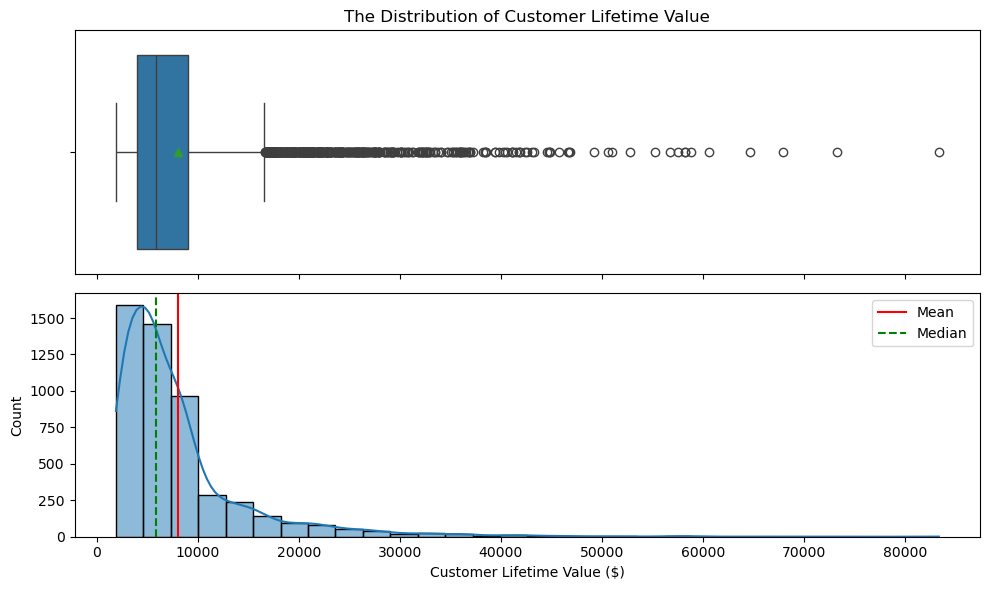

In [12]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.boxplot(data=data, x='Customer Lifetime Value', ax=ax_box, showmeans=True)
sns.histplot(data=data, x='Customer Lifetime Value', ax=ax_hist, bins=30, kde=True)
ax_hist.axvline(data['Customer Lifetime Value'].mean(), color='red', linestyle='-', label='Mean')
ax_hist.axvline(data['Customer Lifetime Value'].median(), color='green', linestyle='--', label='Median')
ax_hist.legend()
ax_box.set_title('The Distribution of Customer Lifetime Value')
ax_hist.set_xlabel('Customer Lifetime Value ($)')
ax_hist.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [13]:
# Outliers detection using IQR method
Q1 = data['Customer Lifetime Value'].quantile(0.25)
Q3 = data['Customer Lifetime Value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f'The upper bound for detecting outliers using the IQR method is: {upper_bound}')
outliers = data[data['Customer Lifetime Value'] > upper_bound]
print(f'There are {outliers.shape[0]} outliers in the dataset based on the IQR method.')

The upper bound for detecting outliers using the IQR method is: 16624.75007525
There are 449 outliers in the dataset based on the IQR method.


In [14]:
# Check the skewness 
print(f'The skewness of the Customer Lifetime Value is {data["Customer Lifetime Value"].skew():.2f}.')

The skewness of the Customer Lifetime Value is 3.11.


Observations: 
- Customer Lifetime Value distribution is highly right-skewed with 3.11 skewness score (>1 means highly skew). CLV also has a right long tail that indicates outliers in CLV that also confirmed through its boxplot
- Most customers have CLV around $8000-$10000 with a noticable gap when the CLV more than $10000.
- The number of customers with CLV >$10000 only a little and this small number of customers that also outliers show there are very valuable customers since maximum CLV could achive >$80000. We can use this to categorize customer with CLV (or will predicted) more than $10000 as loyal customer or high CLV
- Customer Lifetime Value will be our targeted features and this highly right-skewed could be a big troubled to our model to accurately predicting. So, we need to transform Customer Lifetime Value in to log transformation in modeling

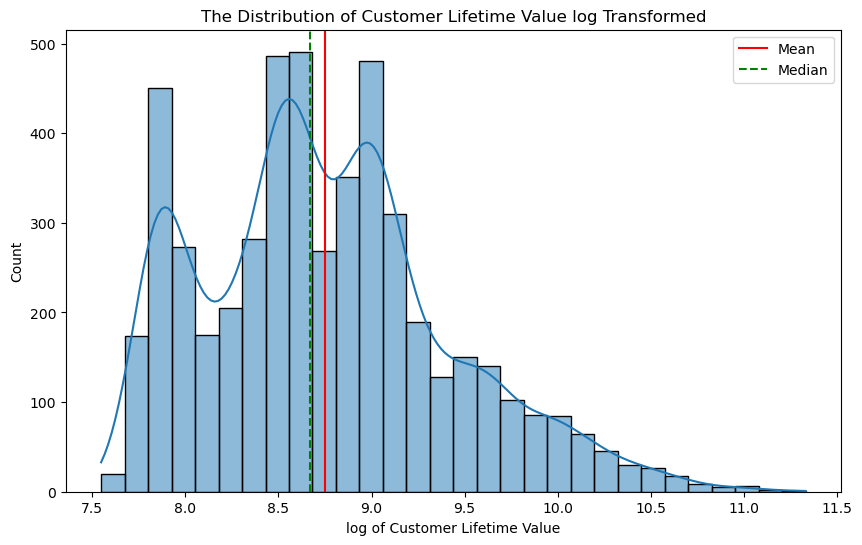

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log(data['Customer Lifetime Value']), bins=30, kde=True)
plt.axvline(np.log(data['Customer Lifetime Value']).mean(), color='red', linestyle='-', label='Mean')
plt.axvline(np.log(data['Customer Lifetime Value']).median(), color='green', linestyle='--', label='Median')
plt.legend()
plt.title('The Distribution of Customer Lifetime Value log Transformed')
plt.xlabel('log of Customer Lifetime Value')
plt.ylabel('Count')
plt.show()

In [16]:
# Check the skewness 
print(f'The skewness of the log transformed Customer Lifetime Value is {np.log(data["Customer Lifetime Value"]).skew():.2f}.')

The skewness of the log transformed Customer Lifetime Value is 0.57.


We can see, that the distribution of log transform in Customer Lifetime Value is better than the original. The skewedness also reduce a lot from 3.11 in to 0.57. So, we will used this log transformation in to modeling and inversed it again to interpret the result. 

In [17]:
data[data['Customer Lifetime Value'] > 60000]

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value
849,Luxury Car,Extended,Offer1,Unemployed,Married,High School or Below,2,217,1562.400000,0.0,64618.75715
1014,Luxury SUV,Extended,Offer1,Unemployed,Married,College,2,204,979.200000,0.0,60556.19213
1091,Luxury Car,Extended,Offer1,Employed,Married,High School or Below,2,231,1108.800000,58958.0,83325.38119
1311,Luxury SUV,Extended,Offer1,Employed,Married,Bachelor,2,202,969.600000,39547.0,73225.95652
1527,Sports Car,Premium,Offer1,Employed,Married,Bachelor,2,192,151.711475,78310.0,67907.27050


In [18]:
# Drop extreme outliers
data = data.drop(data[data['Customer Lifetime Value'] > 60000].index)
print(f'This dataset contains {data.shape[0]} rows and {data.shape[1]} columns after removing extreme outliers.')

This dataset contains 5046 rows and 11 columns after removing extreme outliers.


**Monthly Premium Auto**

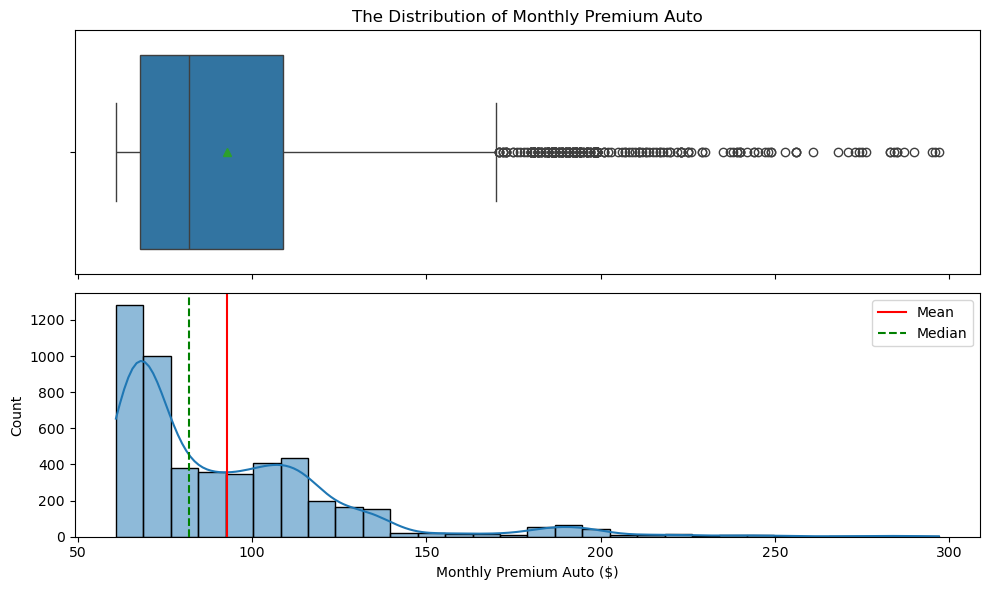

In [19]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.boxplot(data=data, x='Monthly Premium Auto', ax=ax_box, showmeans=True)
sns.histplot(data=data, x='Monthly Premium Auto', ax=ax_hist, bins=30, kde=True)
ax_hist.axvline(data['Monthly Premium Auto'].mean(), color='red', linestyle='-', label='Mean')
ax_hist.axvline(data['Monthly Premium Auto'].median(), color='green', linestyle='--', label='Median')
ax_hist.legend()
ax_box.set_title('The Distribution of Monthly Premium Auto')
ax_hist.set_xlabel('Monthly Premium Auto ($)')
ax_hist.set_ylabel('Count')
plt.tight_layout()
plt.show()

Observations:
- It's clear that monthly premium auto distribution's shape is extremely right-skewed with long right tail. This is shows that there are outliers in Monthly Premium Auto
- Based on the histogram, we can see the distribution shape categorical because besides the highest peak on below the median, there are another peak above the mean. So, we will binned them to help the model learn the pattern easily because it will reduce the unique value.
- For simplify and based in histogram shape, we will binned them in $25 gap

In [20]:
# Binned 'Monthly Premium Auto'
bins = [50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300]
labels = ['50-75', '76-100', '101-125', '126-150', '151-175', '176-200', '201-225', '226-250', '251-275', '276-300']

data['Monthly Premium Auto Binned'] = pd.cut(data['Monthly Premium Auto'], bins=bins, labels=labels, right=True)

# Convert Monthly Premium Auto Binned into categorical type
data['Monthly Premium Auto Binned'] = data['Monthly Premium Auto Binned'].astype('category')

# Check the unique values
data['Monthly Premium Auto Binned'].unique()

['76-100', '50-75', '101-125', '126-150', '176-200', '151-175', '201-225', '276-300', '226-250', '251-275']
Categories (10, object): ['50-75' < '76-100' < '101-125' < '126-150' ... '201-225' < '226-250' < '251-275' < '276-300']

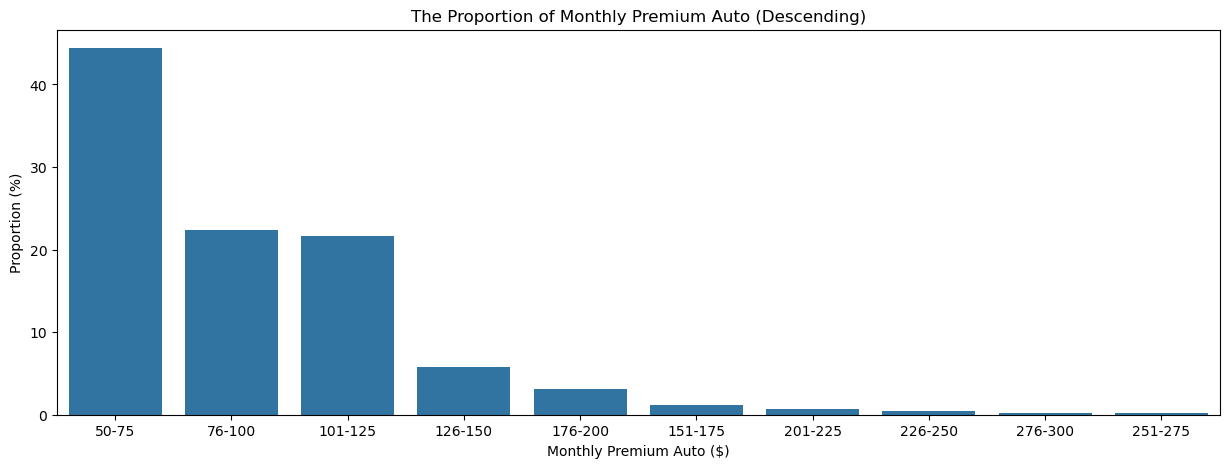

In [21]:
plt.figure(figsize=(15, 5))
ax = sns.countplot(data=data, x='Monthly Premium Auto Binned', order=data['Monthly Premium Auto Binned'].value_counts().index, stat='percent')

ax.set_title('The Proportion of Monthly Premium Auto (Descending)')
ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Monthly Premium Auto ($)')

plt.show()

Observations:
- Most customers have monthly premium between $50-$75 that is about over 40%, then following with customers that has monthly premium between $76-$100 and $101-$125 that has almost similar number of customers which are over 20%
- We can see that most customers assigned to the lowest class of insurances with the lowest monthly premium auto. Total customers who assigned to Monthly Premium Auto higher than $125 less than 20%
- The number of customers who assigned to monthly premium auto higher than $125 is small which means that just a few customers who assigned to insurance product with high monthly premium

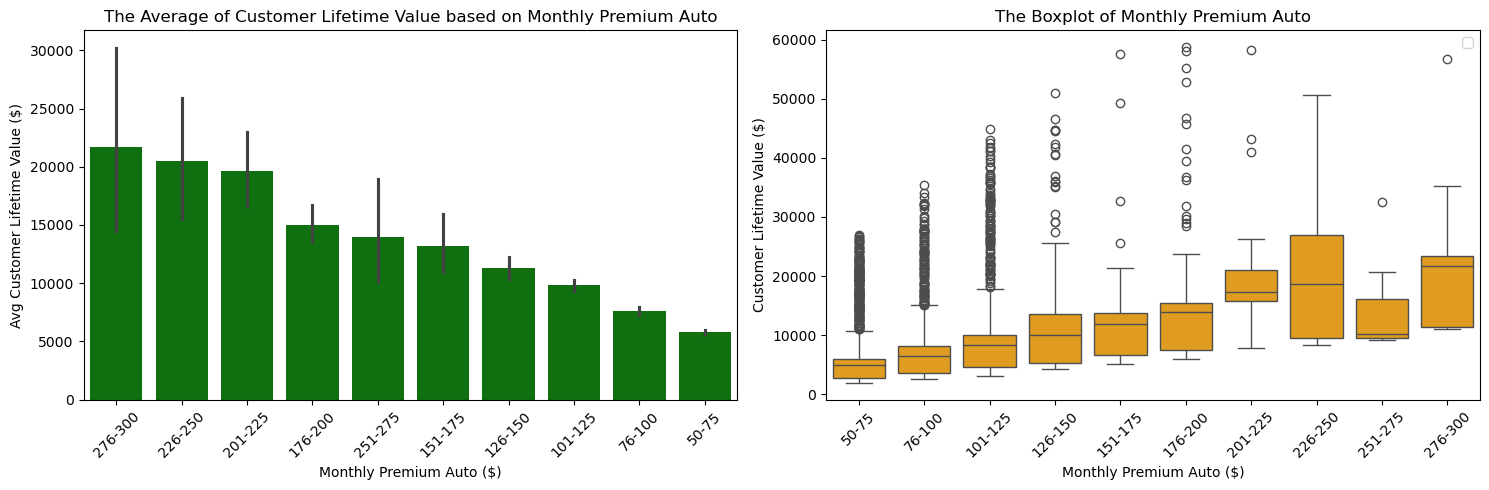

In [22]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

# Histogram
agg = data.groupby('Monthly Premium Auto Binned').agg(
    mean=('Customer Lifetime Value', 'mean')  # Average monthly premium auto
).reset_index()
orders = agg.sort_values('mean', ascending=False)['Monthly Premium Auto Binned']

sns.barplot(data=data, x='Monthly Premium Auto Binned', y='Customer Lifetime Value', estimator=np.mean, ax=axes[0], color='green', order=orders)
axes[0].set_xlabel('Monthly Premium Auto ($)')
axes[0].set_ylabel('Avg Customer Lifetime Value ($)')
axes[0].set_title(f'The Average of Customer Lifetime Value based on Monthly Premium Auto')
axes[0].tick_params(axis='x', rotation=45)

# Histogram
sns.boxplot(data=data, x='Monthly Premium Auto Binned', y='Customer Lifetime Value', ax=axes[1], color='orange')
axes[1].set_xlabel('Monthly Premium Auto ($)')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Boxplot of Monthly Premium Auto')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- From the relationship of Monthly Premium with the Customer Lifetime Value, we can see that they have positive correlation which means higher the monthly Premium Auto will be lead to higher CLV
- This might be explain why the distribution shape between Monthly Premium Auto almost similar with Customer Lifetime Value
- Based on the barplot, we can see a noticable gap when the Monthly Premium is higher than $200. But, from the previous chart we see that the number of customer who got monthly premium higher than $200 is small and there are outliers and high variances in the average, we can't really sure the monthly premium auto higher that $200 will be definitely lead to higher CLV.

**Total Claim Amount**

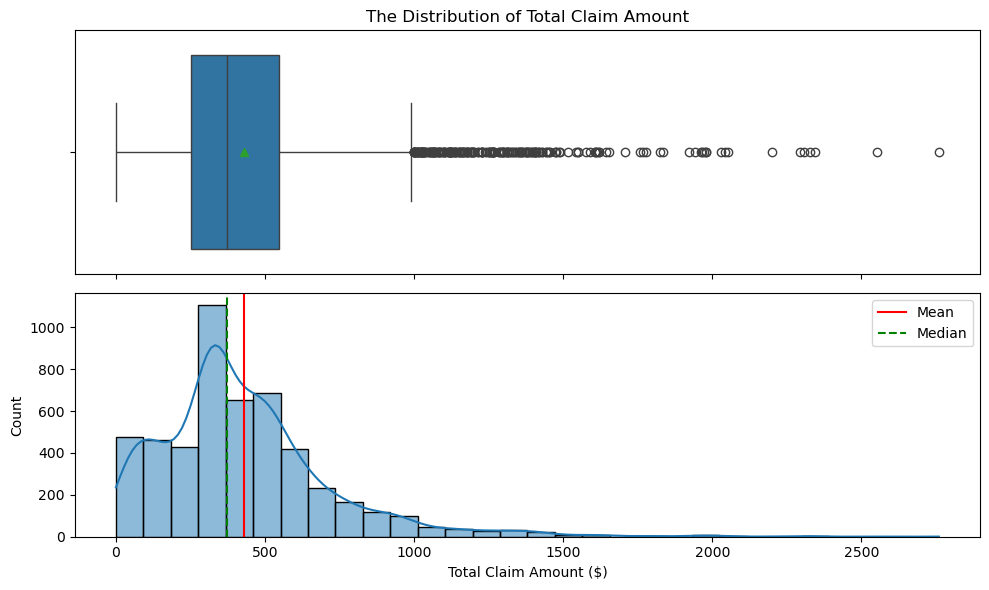

In [23]:
fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
sns.boxplot(data=data, x='Total Claim Amount', ax=ax_box, showmeans=True)
sns.histplot(data=data, x='Total Claim Amount', ax=ax_hist, bins=30, kde=True)
ax_hist.axvline(data['Total Claim Amount'].mean(), color='red', linestyle='-', label='Mean')
ax_hist.axvline(data['Total Claim Amount'].median(), color='green', linestyle='--', label='Median')
ax_hist.legend()
ax_box.set_title('The Distribution of Total Claim Amount')
ax_hist.set_xlabel('Total Claim Amount ($)')
ax_hist.set_ylabel('Count')
plt.tight_layout()
plt.show()

Observations:
- Based on total claimed amount histogram, the peak happen around $300-$400. 
- The shape looks closer with bell shaped compared to Monthly Premium Auto and Customers Lifetime Value, but it still have long righ-tail that informed us there are outliers here for the maximum total claim amount could reach over $2500. 
- The shape of total claim amount distribution is right-skewed with righ long tail that showed there are outliers here

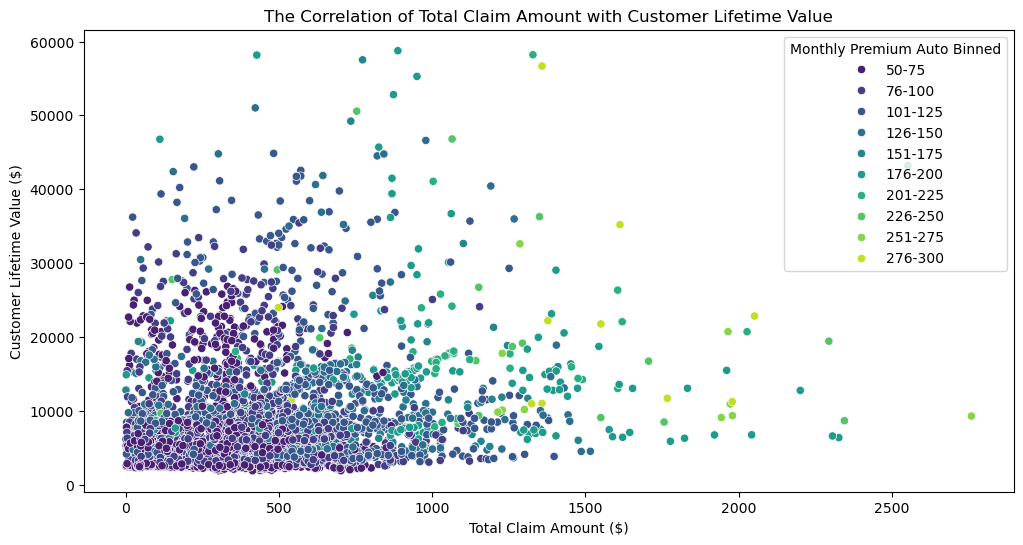

In [24]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x='Total Claim Amount', y='Customer Lifetime Value', hue='Monthly Premium Auto Binned', palette='viridis')
plt.xlabel('Total Claim Amount ($)')
plt.ylabel('Customer Lifetime Value ($)')
plt.title('The Correlation of Total Claim Amount with Customer Lifetime Value')
plt.show()

In [25]:
data['Customer Lifetime Value'].corr(data['Total Claim Amount'], 'spearman')

0.19009284248994054

Observations:
- The scatter plot shows no strong linear relationship between Total Claim Amount and Customer Lifetime Value (CLV). This is supported by the Spearman correlation coefficient of 0.19, which indicates only a very weak positive correlation.
- Most customers are concentrated in the lower ranges (Total Claim Amount < 1000 and Customer Lifetime Value < 30,000). Within this region, the majority of customers fall into low-to-mid Monthly Premium Auto categories ($50–$150), represented by darker shades in the plot.
- Conceptually, CLV often decreases when claims increase, since claims reduce profitability. However, the dataset shows a slightly positive correlation. This suggests that some high-value customers (long-term, loyal, or high-paying premium holders) are also making higher claims. This could imply that insurance companies tolerate higher claim amounts from customers with high monthly premiums or long-term policies, as these customers are still profitable overall.
- Higher Monthly Premium Auto categories (lighter green/yellow shades) tend to appear in the upper ranges of both CLV and Total Claim Amount. This indicates that customers paying higher premiums are more likely to have higher lifetime value and make larger claims (likely due to insuring higher-value vehicles).
- There are several outliers where Customer Lifetime Value exceeds 60,000–80,000 and Total Claim Amount > 2000. These outliers are mostly associated with customers in high premium categories (≥ 200). These extreme cases may represent VIP customers or individuals with very expensive vehicles.
- Customers in low premium categories (dark color) are densely clustered at low CLV and claim values, suggesting lower-risk but also lower-value customers for the company. In contrast, customers in higher premium categories are more widely dispersed, covering both high and low CLV, but with more potential for large claims. This is a classic high-risk, high-return customer segment.

**Number of Policies**

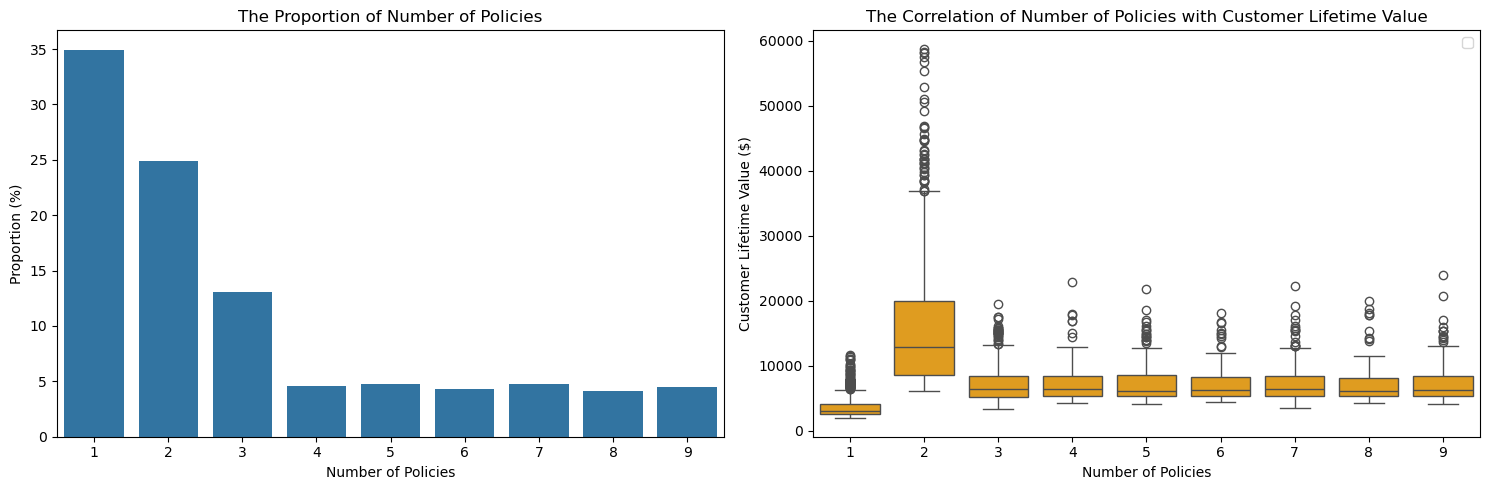

In [26]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Number of Policies', stat='percent', ax=axes[0])
axes[0].set_xlabel('Number of Policies')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Number of Policies')

# Histogram
sns.boxplot(data=data, x='Number of Policies', y='Customer Lifetime Value', ax=axes[1], color='orange')
axes[1].set_xlabel('Number of Policies')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Number of Policies with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- As shown in the count plot, 35% of customers hold only 1 policy, making it the dominant category. However, the Customer Lifetime Value (CLV) of customers holding 1 policy is generally the lowest, which suggests that these customers are either low-risk or do not have much additional coverage. The box plot also highlights that the median CLV for customers with only 1 policy is relatively low compared to other categories.
- There is a notable percentage of customers holding 2 (~25%) and 3 (~14%) policies, suggesting the popularity of bundling or multi-coverage options. The box plot shows that the CLV for customers holding 2 policies has a wider range, with some customers reaching over $80,000 in CLV, while others remain below $30,000. This indicates that multi-policy customers may still vary greatly in terms of loyalty, spending, and lifetime value, but they generally show greater value than those with only 1 policy.
- After 3 policies, there is a significant decline in the proportion of customers holding 4–9 policies, with each category representing only ~5% of the total. This is visually confirmed by the box plot, where customers with more than 3 policies show lower median CLV, usually under $30,000.
- Customers who hold 4-9 policies may represent a niche market—either high-value clients with specific needs or business accounts insuring multiple assets. However, the CLV in these categories is generally lower than expected, possibly because their policies are more basic, or their total premium contributions are not high.
- The box plot clearly shows that customers holding 2 policies tend to achieve the highest CLV, with some reaching as high as $80,000. This suggests that 2 policies might be the sweet spot where customers are most likely to stay loyal and generate maximum value without overcomplicating their coverage.
- Interestingly, once customers hold more than 2 policies, their CLV drops considerably, with the majority staying under $30,000. This could imply that adding more policies may not be as effective in increasing CLV.
- For single-policy holders, the company could focus on upselling by offering them an additional policy, especially to those in the 1-policy group, who have a low CLV. A 2-policy bundle could be presented as a way to increase value.
- For customers with more than 2 policies, the company could offer simplified coverage options to consolidate multiple policies into a more streamlined package. This may help reduce administrative complexity and increase satisfaction. The company could explore offering bundled plans that include various coverage types under one plan, possibly increasing retention and satisfaction.

**Income**

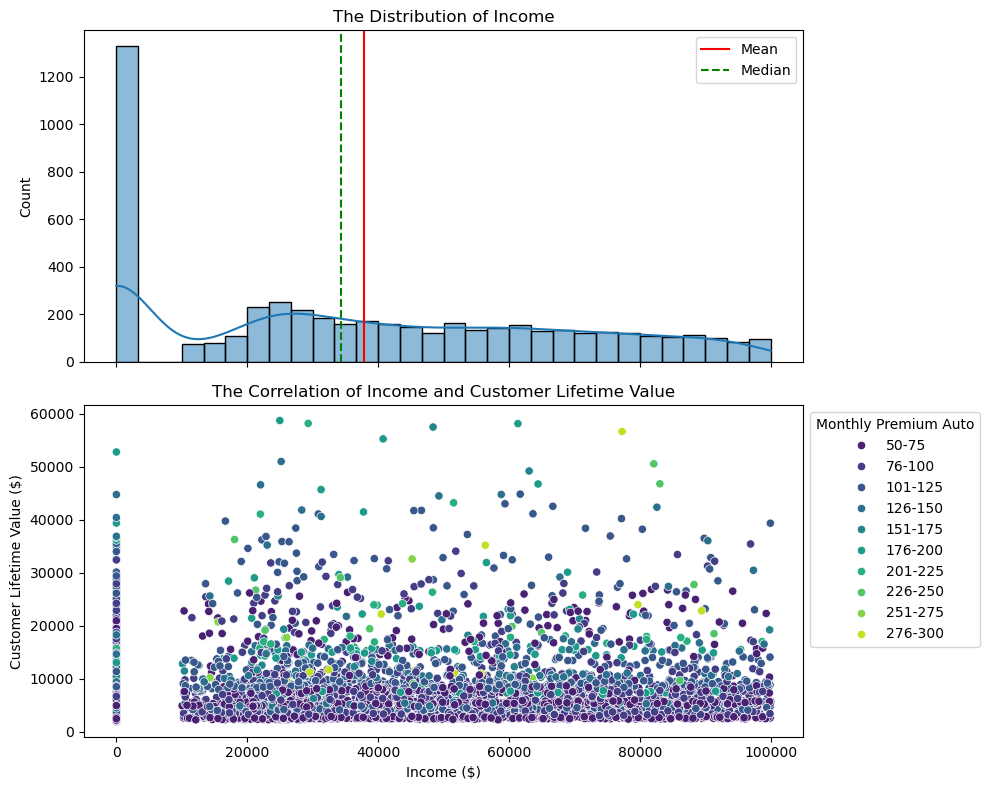

In [27]:
fig, ax = plt.subplots(2,1, sharex=True, figsize = (10,8))

#Histplot
sns.histplot(data=data, x='Income', bins=30, kde=True, ax=ax[0])
ax[0].axvline(data['Income'].mean(), color='red', linestyle='-', label='Mean')
ax[0].axvline(data['Income'].median(), color='green', linestyle='--', label='Median')
ax[0].set_ylabel('Count')
ax[0].set_title('The Distribution of Income')
ax[0].legend()

#Scatterplot
sns.scatterplot(data=data, x='Income', y='Customer Lifetime Value', ax=ax[1], hue='Monthly Premium Auto Binned', palette='viridis')
ax[1].set_xlabel('Income ($)')
ax[1].set_ylabel('Customer Lifetime Value ($)')
ax[1].set_title('The Correlation of Income and Customer Lifetime Value')
# Adjust the legend to move it outside the plot
ax[1].legend(title="Monthly Premium Auto", loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [28]:
data['Customer Lifetime Value'].corr(data['Income'], 'spearman')

0.06305526404940538

In [29]:
print(f'Customers having Income 0 are about {round(data[data["Income"]==0].shape[0]/data.shape[0]*100, 2)}%')
print(f'Customers who having Income 0 is {data[data["Income"]==0]["EmploymentStatus"].unique()} Employment Status')
print(f'Minimal income of Customers who having >0 Income is ${round(data[data["Income"] > 0]["Income"].min())}')

Customers having Income 0 are about 26.36%
Customers who having Income 0 is ['Unemployed'] Employment Status
Minimal income of Customers who having >0 Income is $10037


Observations:
- A significant portion of the customers (around 26.37%) show an Income of 0. They are Unemployed Employment Status, indicating that they are either students or housewives, individuals who are likely financially supported by others, yet they still pay for a Monthly Premium Auto that span from low to mid-high values. These situation make possibility for 0 Income Customer to have high Customer Lifetime Value.
- For customers with non-zero income, the distribution falls within the $10,000 - $100,000 range, with a notable peak around $25,000 per year. This could represent middle-income earners, which is common for many populations. The spread of income is relatively wide, indicating that there are customers across various income brackets.
- The scatterplot suggests that there is no strong correlation between Income and Customer Lifetime Value. This is further confirmed by the Spearman's correlation coefficient of ~0.06, indicating a very weak positive relationship between the two variables. This implies that Income is not a strong predictor of CLV.

**Vehicle Class**

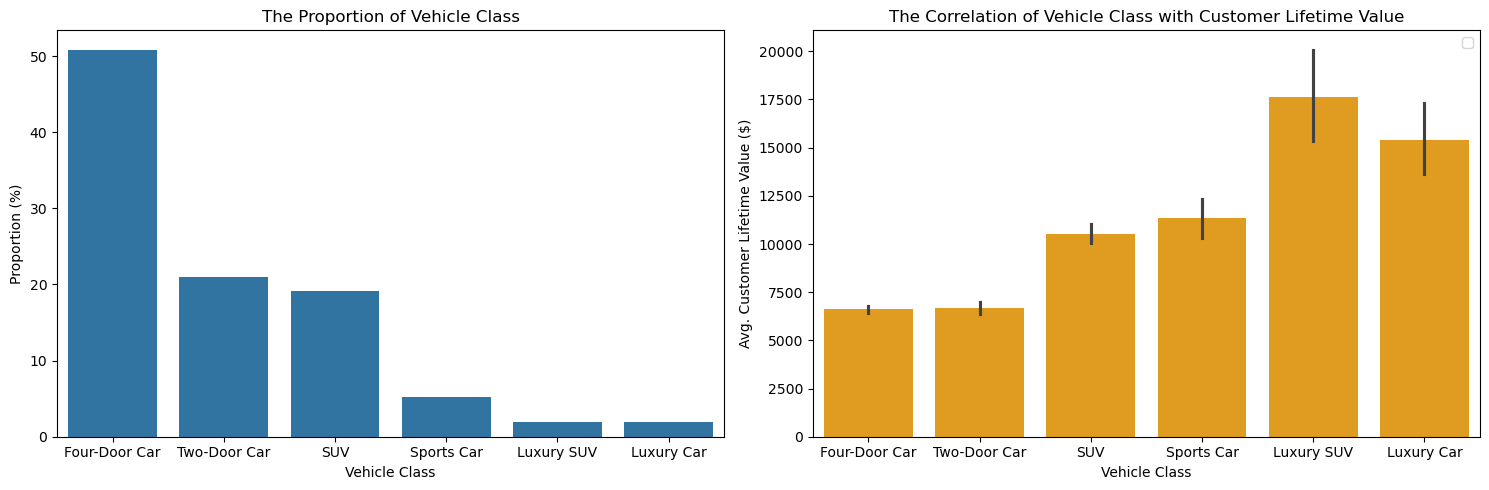

In [30]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Vehicle Class', stat='percent', ax=axes[0])
axes[0].set_xlabel('Vehicle Class')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Vehicle Class')

# Histogram
sns.barplot(data=data, x='Vehicle Class', y='Customer Lifetime Value', estimator=np.mean, ax=axes[1], color='orange')
axes[1].set_xlabel('Vehicle Class')
axes[1].set_ylabel('Avg. Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Vehicle Class with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

In [31]:
print('The Monthly Premium Auto for each Vehicle Class')
for i in data['Vehicle Class'].unique():
    premiums = data[data["Vehicle Class"]==i]["Monthly Premium Auto Binned"].unique()
    print(f'{i}: {list(premiums)}')

The Monthly Premium Auto for each Vehicle Class
Four-Door Car: ['76-100', '50-75', '101-125']
Two-Door Car: ['50-75', '76-100', '101-125']
SUV: ['101-125', '126-150', '76-100', '151-175', '176-200']
Sports Car: ['101-125', '76-100', '126-150', '151-175', '176-200']
Luxury SUV: ['176-200', '276-300', '201-225', '251-275', '226-250']
Luxury Car: ['176-200', '201-225', '226-250', '251-275', '276-300']


In [32]:
# Proportion of 'Two-Door Car', 'Four-Door Car', 'SUV' among all customers
subset = data['Vehicle Class'].isin(['Two-Door Car', 'Four-Door Car', 'SUV'])
print(f"Proportion of selected classes: {subset.mean():.2%}")

Proportion of selected classes: 90.90%


In [33]:
subset_data = data[subset]
subset_data.head()

,Vehicle Class,Coverage,Renew Offer Type,EmploymentStatus,Marital Status,Education,Number of Policies,Monthly Premium Auto,Total Claim Amount,Income,Customer Lifetime Value,Monthly Premium Auto Binned
0,Four-Door Car,Extended,Offer1,Retired,Divorced,High School or Below,2,90,571.479602,11828.0,10083.486880,76-100
1,Four-Door Car,Basic,Offer1,Employed,Married,College,6,62,114.514440,44762.0,4943.386117,50-75
2,Two-Door Car,Basic,Offer1,Retired,Married,Master,2,62,257.248789,21514.0,11981.984810,50-75
3,Four-Door Car,Premium,Offer3,Disabled,Married,High School or Below,1,116,556.800000,17913.0,4550.856045,101-125
4,Two-Door Car,Basic,Offer3,Medical Leave,Married,High School or Below,1,62,355.820799,19030.0,2372.155492,50-75


Observations:
- Four-Door Cars dominate the portfolio, accounting for about 50% of the dataset. This highlights the company’s strong customer base in family-oriented, middle-class vehicles. Two-Door Cars and SUVs follow, each at roughly 20%, making them substantial but secondary markets. Sports Cars, Luxury SUVs, and Luxury Cars together represent only a small niche, reinforcing the idea that the company mainly serves middle-class customers, while luxury owners form a minority.
- The highest average CLV is found in Luxury SUVs, followed by Luxury Cars. This reflects their higher Monthly Premium Auto ranges ($176–300), which directly drive CLV upwards.Conversely, Four-Door Cars and Two-Door Cars generate the lowest CLV, even though they make up the majority of customers. Their Monthly Premium Auto lies in the $50–125 range, keeping CLV relatively low. SUVs and Sports Cars fall in the mid-range premiums ($76–200), yielding higher CLV than standard cars but still below the luxury segment.
- The comparison clearly shows that Monthly Premium Auto is strongly related to CLV: Economy cars → low premiums → low CLV, SUVs/Sports Cars → mid premiums → moderate CLV, and Luxury SUVs/Cars → high premiums → high CLV
- Among the common vehicle classes, SUVs stand out as an attractive segment because they have a decent share of customers (~20%) yet yield significantly higher CLV than standard Four-Door and Two-Door cars for their higher premium bands. This makes SUV customers a promising target group for boosting overall CLV without depending solely on the small luxury market.
- To boost overall CLV, the company could design tiered product offerings:
    - Economy package for Four-/Two-Door Cars → focus on affordability and loyalty rewards to keep the large customer base engaged.
    - Premium package for SUVs → highlight safety, family coverage, and bundled benefits (e.g., multi-car discounts).
    - Elite package for Luxury SUVs/Cars → emphasize concierge-style service, comprehensive coverage, and exclusivity.

**Coverage**

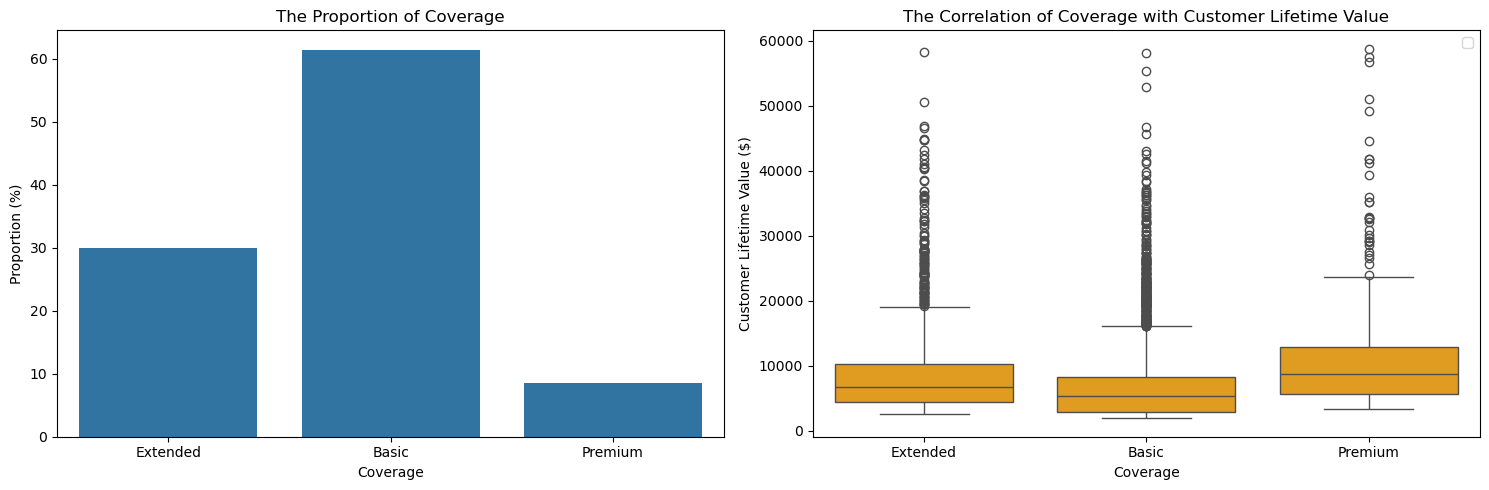

In [34]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Coverage', stat='percent', ax=axes[0])
axes[0].set_xlabel('Coverage')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Coverage')

# Histogram
sns.boxplot(data=data, x='Coverage', y='Customer Lifetime Value', ax=axes[1], color='orange')
axes[1].set_xlabel('Coverage')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Coverage with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

In [35]:
print('The Monthly Premium Auto for each Coverage')
for i in data['Coverage'].unique():
    premiums = data[data["Coverage"]==i]["Monthly Premium Auto Binned"].unique()
    print(f'{i}: {list(premiums)}')

The Monthly Premium Auto for each Coverage
Extended: ['76-100', '126-150', '101-125', '201-225', '226-250']
Basic: ['50-75', '101-125', '76-100', '176-200']
Premium: ['101-125', '151-175', '126-150', '176-200', '276-300', '251-275']


Observations:
- The majority of customers (~60%) opt for Basic Coverage, making it the company’s core product. Extended Coverage follows with about 30%, while Premium Coverage is the least chosen option, at around 10%. This shows that customers prefer more affordable plans, but there’s still a notable group choosing higher coverage.
- While Premium Coverage has the highest range of Monthly Premium Auto ($101–300), it does not necessarily dominate in CLV. Extended Coverage achieves comparable or even higher CLV potential than Premium, despite being a mid-tier product (Monthly Premium range: $76–250). Basic Coverage produces the lowest CLV, consistent with its lower Monthly Premium range ($50–200).
- Extended Coverage sits in the middle premium range, yet delivers high CLV performance similar to Premium. This makes Extended Coverage a strategically important product because it appeals to a larger share of customers than Premium, while still generating strong value for the company.

**Renew Offer Type**

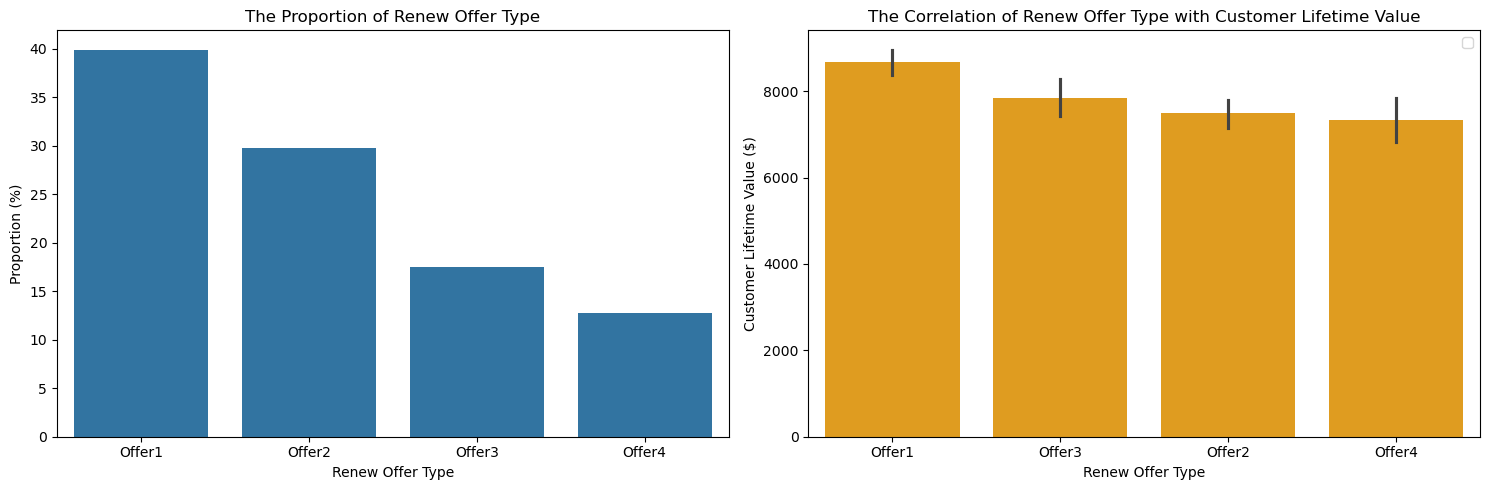

In [36]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Renew Offer Type', stat='percent', ax=axes[0], order=data['Renew Offer Type'].value_counts().index)
axes[0].set_xlabel('Renew Offer Type')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Renew Offer Type')

# Histogram
sns.barplot(data=data, x='Renew Offer Type', y='Customer Lifetime Value', estimator=np.mean, ax=axes[1], color='orange')
axes[1].set_xlabel('Renew Offer Type')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Renew Offer Type with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- Offer Type 1 is clearly the most commonly used, representing almost 40% of the total, followed by Offer Type 2 at around 30%. Offer Types 3 and 4 make up smaller proportions, indicating they are less frequently offered. This pattern may suggest that the company primarily uses Offer Type 1 as the default offer, moving to the next types (Offer 2, 3, and 4) only if the previous ones are not accepted. This would make sense as a sequential offer strategy.
- The average CLV for all Renew Offer Types (1, 2, 3, and 4) is very similar with minimal variation. This suggests that the choice of offer type has little to no impact on CLV, meaning customers who are offered any of these options tend to have comparable lifetime value, regardless of which specific offer they receive. The sequential offering strategy may be more about ensuring continuity rather than maximizing CLV.

**Employment Status**

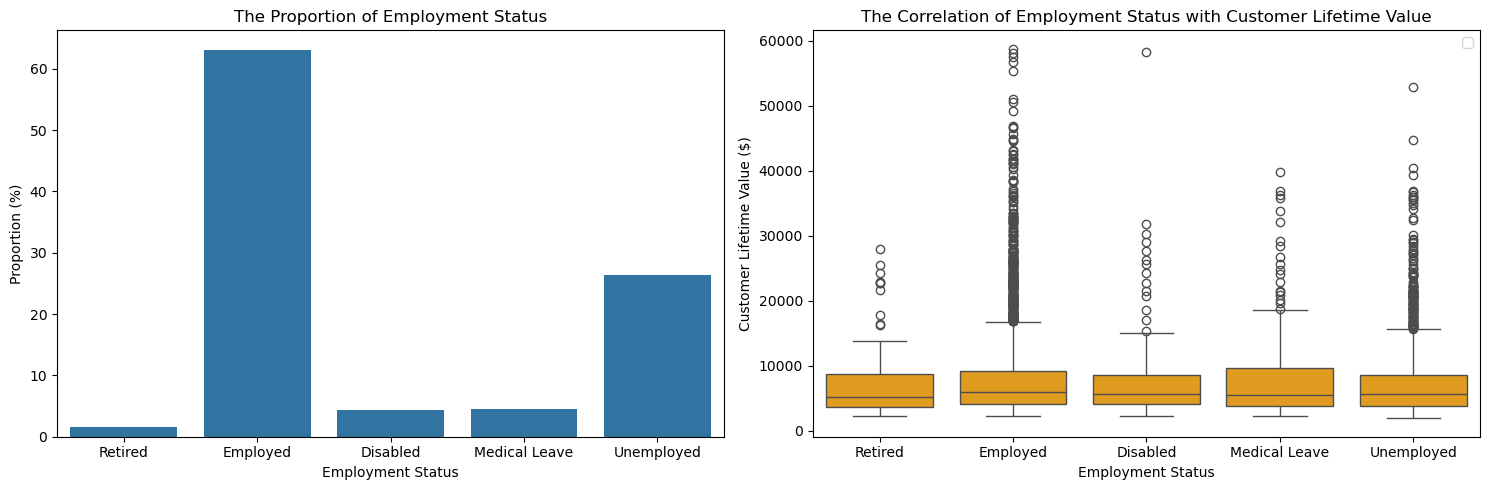

In [37]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='EmploymentStatus', stat='percent', ax=axes[0])
axes[0].set_xlabel('Employment Status')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Employment Status')

# Histogram
sns.boxplot(data=data, x='EmploymentStatus', y='Customer Lifetime Value', ax=axes[1], color='orange')
axes[1].set_xlabel('Employment Status')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Employment Status with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- Employed customers represent over 60% of the total, highlighting that the company’s primary focus is on working-class families, which is a typical target market for insurance companies. Unemployed customers follow at about 30%, suggesting that a significant portion of the customer base is financially supported by others, likely through family or spousal support. The remaining categories (Retired, Disabled, and Medical Leave) make up less than 10% each, indicating they form a minority of the customer base.
- Employed customers hold the highest CLV, which is expected because they are likely paying higher premiums and have longer-term financial stability. Unemployed customers also achieve significant CLV, likely due to their ability to afford premiums through external support (family or savings). Despite having zero income, these customers still maintain strong CLV, as they might be long-term policyholders.
- Retired, Disabled, and Medical Leave categories show lower CLV, likely due to their reduced income or dependency on fixed pensions or disability benefits, which limits their premium-paying capacity. The company could retain these customers by providing discounts or low-cost coverage options, which would ensure their retention and possibly increase long-term CLV even if the premiums are lower.

**Marital Status**

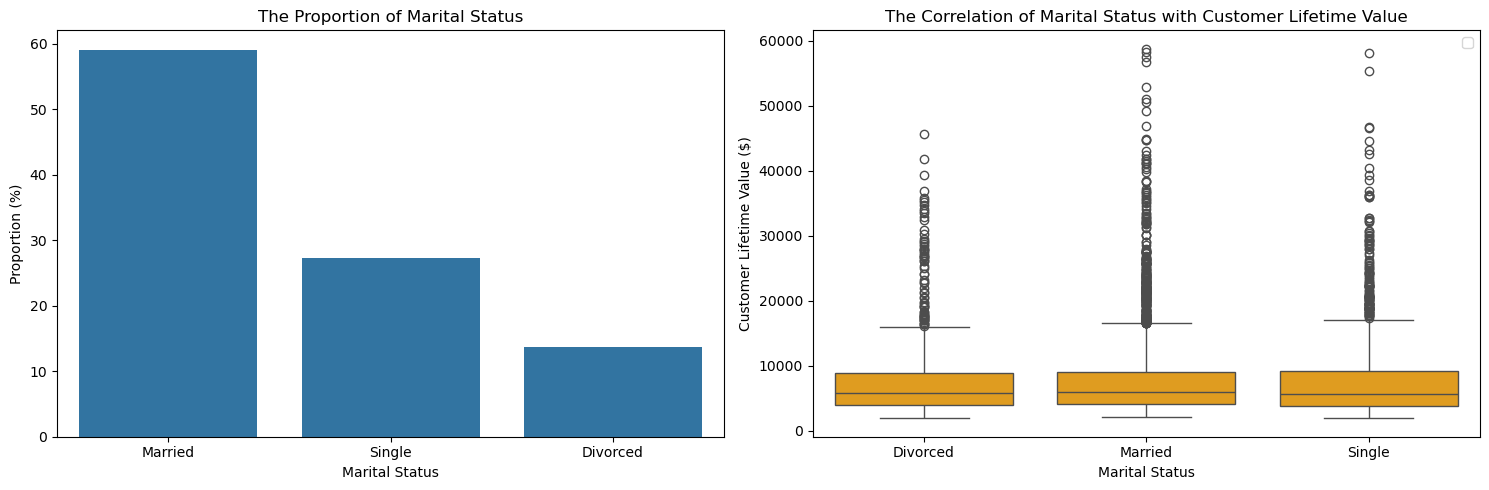

In [38]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Marital Status', stat='percent', ax=axes[0], order=data['Marital Status'].value_counts().index)
axes[0].set_xlabel('Marital Status')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Marital Status')

# Histogram
sns.boxplot(data=data, x='Marital Status', y='Customer Lifetime Value', ax=axes[1], color='orange')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Marital Status with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- The large proportion of married customers (~60%) and the higher Customer Lifetime Value (CLV) range associated with them suggest that married customers may be more likely to purchase long-term insurance plans. This is consistent with previous insight that the primary market consists of middle working-class families, where car insurance could be seen as a key financial product to ensure family security and well-being.
- The relatively smaller proportion of single and divorced customers, with their lower CLV, indicates that these segments may not prioritize car insurance as highly as married customers. However, this does not rule out targeted campaigns to address their specific needs, especially single professionals or divorced individuals who may prioritize different types of coverage or flexible terms.
- There is an opportunity for the company to develop personalized insurance packages that cater specifically to the needs of married individuals, such as family-friendly policies, multi-car discounts, or plans that cover dependents. On the other hand, offering more flexible, short-term policies with lower premiums could attract single or divorced customers who may not see a need for extensive coverage.

**Education**

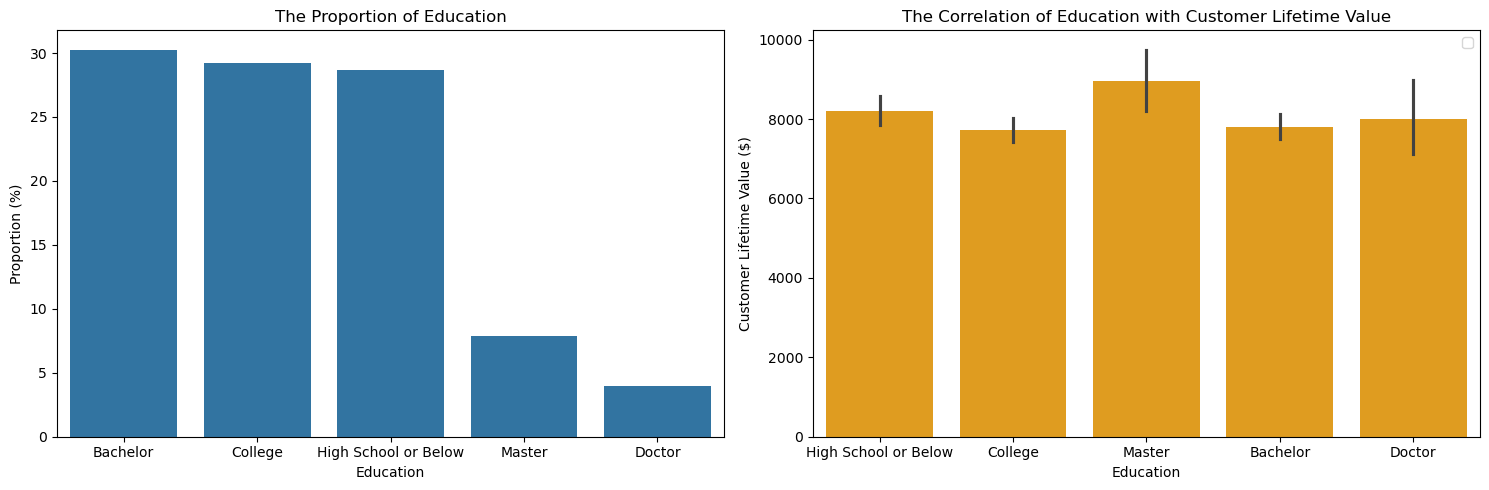

In [39]:
# Visualize Monthly Premium Auto using boxplot and histogram
fig, axes = plt.subplots(1,2, figsize = (15,5))

sns.countplot(data=data, x='Education', stat='percent', ax=axes[0], order=data['Education'].value_counts().index)
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Proportion (%)')
axes[0].set_title(f'The Proportion of Education')

# Histogram
sns.barplot(data=data, x='Education', y='Customer Lifetime Value', estimator=np.mean, ax=axes[1], color='orange')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Customer Lifetime Value ($)')
axes[1].set_title(f'The Correlation of Education with Customer Lifetime Value')

plt.tight_layout()
plt.legend()
plt.show()

Observations:
- The majority of customers hold a Bachelor, College, or High School-or-below level of education, each making up close to one-third of the population. Only a small minority of customers have attained Master’s or Doctoral degrees (together <15%). This confirms that the company’s primary customer base is concentrated in the middle education spectrum, aligning with the middle working-class market focus.
- Education does not appear to be a strong predictor of CLV; the variance between categories is minor compared to what we might expect if education were a key driver. This suggests that other factors may play a more dominant role in influencing CLV.

**EDA Conclusions:**
- Significant CLV Drivers (from statistical test):
	- Vehicle Class (SUVs & Luxury cars → higher CLV)
	- Coverage (Extended → higher CLV than Basic)
	- Renew Offer Type
	- Employment Status (Employed → higher CLV)
	- Number of Policies (max. 2 policies → sharp increase in CLV)
	- Monthly Premium Auto (higher premium → higher CLV)
- Main Focus Market (sweet spot for CLV):
	- Middle to upper-income married, employed customers
	- Owners of SUVs and luxury vehicles
	- Willing to pay higher monthly premiums
	- Holding at least two policies
	- Prefer Extended Coverage
- Strategic Implications:
	- Grow: Target SUV & luxury car owners with tailored bundles.
	- Upsell: Encourage single-policy customers to adopt 2+ policies.
    - Simplify: Encourage more than 2-policy customers to simplify of bundling their policies into 2 policies.
	- Retain: Loyalty programs for married & employed customers.

**Statistical Test on Category Predictors**

To examine the impact of categorical variables on Customer Lifetime Value (CLV), we applied the Kruskal-Wallis statistical test to each categorical feature. The Kruskal-Wallis test was chosen because CLV is not normally distributed, making ANOVA unsuitable for this analysis.

In [40]:
data = data.drop(columns=['Monthly Premium Auto Binned'])

In [41]:
for col in data.select_dtypes(include=['object', 'category']).columns:
    groups = [group['Customer Lifetime Value'].values 
              for _, group in data.groupby(col)]

    # Perform Kruskal-Wallis H-test
    stat, p = kruskal(*groups)

    if p < 0.05:
        print(f'We reject the H0. The mean of CLV on {col} is significantly different with p-value: {p:.4f}.')
    else:
        print(f'We fail to reject the H0. The mean of CLV on {col} is NOT significantly different with p-value: {p:.4f}.')

We reject the H0. The mean of CLV on Vehicle Class is significantly different with p-value: 0.0000.
We reject the H0. The mean of CLV on Coverage is significantly different with p-value: 0.0000.
We reject the H0. The mean of CLV on Renew Offer Type is significantly different with p-value: 0.0000.
We reject the H0. The mean of CLV on EmploymentStatus is significantly different with p-value: 0.0003.
We fail to reject the H0. The mean of CLV on Marital Status is NOT significantly different with p-value: 0.1153.
We fail to reject the H0. The mean of CLV on Education is NOT significantly different with p-value: 0.0880.
We reject the H0. The mean of CLV on Number of Policies is significantly different with p-value: 0.0000.


Observations:
- Based on the Kruskal-Wallis test, only Marital Status and Education do not have a significant effect on CLV. All other categorical features show a significant impact on Customer Lifetime Value.

### **Modeling**

#### Features Engineering

- The numerical variables (Total Claim Amount and Income) have high magnitude values and are notably skewed, with the presence of outliers. To normalize their scales and reduce the impact of outliers, we apply Robust Scaling. This method centers and scales features using statistics that are robust to outliers (median and IQR), ensuring they are on a similar scale as the encoded categorical features (e.g., 0 or 1 values).
- Categorical variables are encoded based on their nature. One-Hot Encoding is applied to Number of Policies, Vehicle Class, Renew Offer Type, Employment Status, and Marital Status, as these are nominal categories with no inherent order. Ordinal Encoding is used for Monthly Premium Auto, Coverage and Education, since their values imply a hierarchy meaning.

**Build Column Transformer of Data Preprocessing**

In [42]:
# Scaling
scaler = RobustScaler()

# Create a pipeline for numerical features
numerical_pipeline = Pipeline(steps=[
    ('scaler', scaler)
])

# Create a pipeline for onehot encoding
onehot_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

#encode categorical variables
ordinal_label = [
    ['Basic', 'Extended', 'Premium'], #Coverage feature
    ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor'], #Education feature
]

# Create a pipeline for ordinal encoding
ordinal_pipeline = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=ordinal_label))
])

In [43]:
transformer = ColumnTransformer([
    ('numerical', numerical_pipeline, ['Total Claim Amount', 'Income', 'Monthly Premium Auto']),
    ('onehot', onehot_pipeline, ['Number of Policies', 'Vehicle Class', 'Renew Offer Type', 'EmploymentStatus', 'Marital Status']),
    ('ordinal', ordinal_pipeline, ['Coverage', 'Education']),
], remainder='passthrough')

In [44]:
preprocessor = Pipeline(steps=[
    ('transformer', transformer)
])

In [45]:
#Define the features and target variable
X = data.drop(columns=['Customer Lifetime Value'])
y = data['Customer Lifetime Value']

#Data splitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Linearity Check**

In [46]:
# Apply the transformations to the features
X_transformed = preprocessor.fit_transform(X_train)
features_names = preprocessor.named_steps['transformer'].get_feature_names_out()
X_df = pd.DataFrame(X_transformed, columns=features_names, index=X_train.index)

In [47]:
# OLS needs intercept
X_const = sm.add_constant(X_df)
# Fit model
model = sm.OLS(y_train, X_const).fit()
# we did not split the data because the goal is to assess the linearity of the relationship between the features and the target variable

print(model.summary())

                               OLS Regression Results                              
Dep. Variable:     Customer Lifetime Value   R-squared:                       0.663
Model:                                 OLS   Adj. R-squared:                  0.660
Method:                      Least Squares   F-statistic:                     255.1
Date:                     Tue, 30 Sep 2025   Prob (F-statistic):               0.00
Time:                             11:41:15   Log-Likelihood:                -34164.
No. Observations:                     3532   AIC:                         6.838e+04
Df Residuals:                         3504   BIC:                         6.856e+04
Df Model:                               27                                         
Covariance Type:                 nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

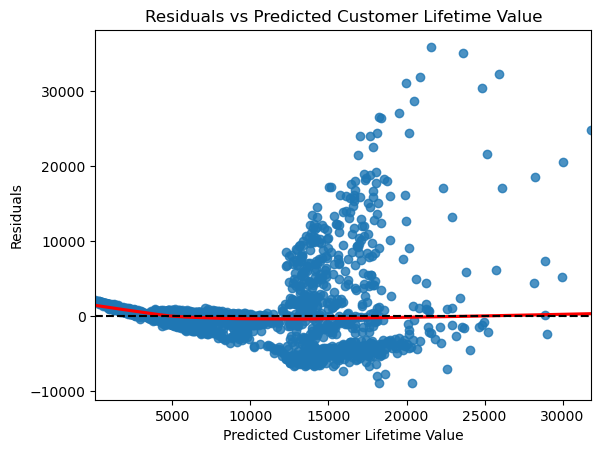

In [48]:
residuals = model.resid
fitted = model.fittedvalues

sns.residplot(x=fitted, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Customer Lifetime Value')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Customer Lifetime Value')
plt.show()

Observations:
- The model achieved an R² of 0.663 and an Adjusted R² of 0.660, meaning the predictors together explain about 66% of the variance in CLV. The closeness of R² and Adjusted R² suggests the model is not heavily overfitted. The Prob(F) = 0.000 indicates that at least one predictor contributes significantly, so the model overall is statistically valid. **This implies the data contains a meaningful linear component, though not perfectly linear**
- Residual analysis shows that the linear model fits reasonably well up to predicted CLV values around ~11,000. Beyond that, the residuals exhibit curvature and increasing spread, indicating non-linearity and heteroskedasticity in higher-value customers. This means the linear assumption holds partially but breaks down for extreme CLV values.
- Based on p-values (< 0.05), the predictors with a statistically significant relationship to CLV are: Monthly Premium Auto, all Number of Policies categories, Renew Offer Type_Offer2, Employment Status Medical Leave. Among these, the largest impact comes from Number of Policies_2 (coef ≈ 12,000), meaning customers with two policies are predicted to have ~12,000 higher CLV compared to the baseline (one policy), holding other factors constant.
- Features with no significant effect (p > 0.05) include: Total Claim Amount, Income, Coverage, Education, most Employment Status categories, Marital Status, and most Vehicle Class categories. These variables do not provide meaningful explanatory power in this linear model.

**Check multicollinearity**

In [49]:
# Apply the transformations to the features
X_transformed = preprocessor.fit_transform(X)
features_names = preprocessor.named_steps['transformer'].get_feature_names_out()
X_df = pd.DataFrame(X_transformed, columns=features_names)


In [50]:
# Multicollinearity test using VIF
X_const = add_constant(X_df)

vif = pd.DataFrame()
vif['Features'] = X_const.columns
vif['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

vif = vif.sort_values(by='VIF', ascending=False).reset_index(drop=True)

In [51]:
vif

,Features,VIF
0,const,41.324937
1,numerical__Monthly Premium Auto,25.418289
2,onehot__Vehicle Class_Luxury SUV,7.971429
3,onehot__Vehicle Class_Luxury Car,7.913563
4,onehot__Vehicle Class_SUV,7.261913
5,onehot__EmploymentStatus_Employed,6.864681
6,onehot__EmploymentStatus_Unemployed,5.815049
7,ordinal__Coverage,5.579505
8,numerical__Income,3.105931
9,onehot__Vehicle Class_Sports Car,3.052861


Observations:
- Among all predictors, only Monthly Premium Auto shows a high VIF (25), which indicates strong multicollinearity. All other variables fall below the common thresholds (VIF < 10), suggesting no major multicollinearity issues.
- Despite the high VIF, Monthly Premium Auto is **retained** because both the EDA and OLS analysis identified it as a key predictor of CLV. Dropping it would remove an important source of explanatory power.
- The high VIF for Monthly Premium Auto is likely due to its strong relationship with Coverage and Vehicle Class, as observed in the EDA. This confirms that premium levels are inherently tied to policy type and vehicle characteristics, which explains the collinearity.

#### **Build Machine Leaning Model**

To build an effective machine learning regression model, the following structured process will be followed:
- We begin by comparing a diverse set of regression models. For the base model, we will used Linear Regression, Decision Tree Regressor, and K-Nearest Neighbors Regressor (KNN). For the ensemble model, we will used Random Forest Regressor, Gradient Boosting Regressor, Ada Boosting Regressor, Bagging Regressor, and XGBoost Regressor. For the regularized linear models we will used Lasso Regression (L1 regularization) and Ridge Regressor (L2 regularization). This broad comparison helps us understand which modeling approach best captures the underlying patterns in our data.
- Our target variable is highly right-skewed, which can impact model performance. To address this, we’ll use TransformedTargetRegressor to apply a log transformation to the target during training and automatically inverse transform it for predictions and evaluation
- To ensure consistency and avoid data leakage, we’ll encapsulate preprocessing and modeling steps into a single Pipeline. This includes scaling using RobustScaler, Polynomial feature expansion, onehot encoding for encode nominal categorical variables, ordinal encoding for ordinal categorical variables, and the estimator itself 
- To ensure reliable performance estimates and mitigate overfitting, we apply 5-fold cross-validation during training. This provides a robust indication of model generalizability on unseen data.
- We will evaluate and compare model performance using RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), MAPE (Mean Absolute Percentage Error), and R² Score (Coefficient of Determination). The lower the MAE, RMSE, and MAPE, the better the model’s accuracy. Conversely, a higher R² indicates a better proportion of variance explained by the model. 
- Once the best-performing model is identified based on cross-validation metrics, we proceed with hyperparameter tuning using GridSearchCV to further optimize performance. The final model will be evaluated on both train and test sets post-tuning to ensure consistent performance and avoid overfitting.
- We also conduct residual analysis to assess model's reliability and performance assumptions by visualizing residual vs. predicted values to assess homoscedasticity (constant variance of errors), plotting residuals to check for randomness (no clear patterns), inspecting residual distribution using histogram to check normality.
- The best model (original or tuned) will be saved using joblib or pickle for future deployment or inference, ensuring reproducibility and reusability.

In [52]:
# Machine learning models
lr = LinearRegression()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()
ada = AdaBoostRegressor()
bag = BaggingRegressor()
knn = KNeighborsRegressor()
xgb = XGBRegressor()
lasso = Lasso()
ridge = Ridge()

# Create log transformation model
log_lr = TransformedTargetRegressor(regressor=lr, func=np.log, inverse_func=np.exp)
log_dt = TransformedTargetRegressor(regressor=dt, func=np.log, inverse_func=np.exp)
log_rf = TransformedTargetRegressor(regressor=rf, func=np.log, inverse_func=np.exp)
log_gb = TransformedTargetRegressor(regressor=gb, func=np.log, inverse_func=np.exp)
log_ada = TransformedTargetRegressor(regressor=ada, func=np.log, inverse_func=np.exp)
log_bag = TransformedTargetRegressor(regressor=bag, func=np.log, inverse_func=np.exp)
log_knn = TransformedTargetRegressor(regressor=knn, func=np.log, inverse_func=np.exp)
log_xgb = TransformedTargetRegressor(regressor=xgb, func=np.log, inverse_func=np.exp)
log_lasso = TransformedTargetRegressor(regressor=lasso, func=np.log, inverse_func=np.exp)
log_ridge = TransformedTargetRegressor(regressor=ridge, func=np.log, inverse_func=np.exp)

In [53]:
# Algorithms preparation (from your code)
models = {
    "Linear Regression": log_lr,
    "Decision Tree": log_dt,
    "Random Forest": log_rf,
    "Gradient Boosting": log_gb,
    "AdaBoost": log_ada,
    "Bagging": log_bag,
    "KNN": log_knn,
    "XGBoost": log_xgb,
    "Lasso": log_lasso,
    "Ridge": log_ridge
}

In [54]:
# Define CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    rmse_scores, mae_scores, mape_scores, r2_scores = [], [], [], []

    for train_idx, test_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Create pipeline
        pipeline = Pipeline(steps=[
            ('preprocessor', transformer),
            ('model', model)
        ])
        
        # Fit & predict
        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)
        
        # Metrics
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        mae_scores.append(mean_absolute_error(y_val, y_pred))
        mape_scores.append(mean_absolute_percentage_error(y_val, y_pred))
        r2_scores.append(r2_score(y_val, y_pred))
    
    # Save results
    results.append({
        "Model": name,
        "RMSE Mean": np.mean(rmse_scores), "RMSE Std": np.std(rmse_scores),
        "MAE Mean": np.mean(mae_scores), "MAE Std": np.std(mae_scores),
        "MAPE Mean": np.mean(mape_scores), "MAPE Std": np.std(mape_scores),
        "R2 Mean": np.mean(r2_scores), "R2 Std": np.std(r2_scores),
    })

# Baseline model
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred = dummy.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results.append({
    "Model": "Dummy Regressor",
    "RMSE Mean": rmse, "RMSE Std": np.std(rmse),
    "MAE Mean": mae, "MAE Std": np.std(mae),
    "MAPE Mean": mape, "MAPE Std": np.std(mape),
    "R2 Mean": r2, "R2 Std": np.std(r2),
})

# Put into DataFrame
results_df = pd.DataFrame(results)

In [55]:
results_df.sort_values(by='RMSE Mean').reset_index(drop=True)

,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,MAPE Mean,MAPE Std,R2 Mean,R2 Std
0,Linear Regression,3709.379698,178.075900,1569.282984,56.191441,0.117522,0.003230,0.684421,0.026500
1,Ridge,3711.596838,179.124482,1568.421662,55.530393,0.117331,0.003085,0.684040,0.026638
2,Gradient Boosting,3726.606327,172.360047,1652.859696,33.121441,0.140591,0.001381,0.682021,0.018885
3,Random Forest,3781.777944,126.140026,1552.567152,22.261451,0.111274,0.002212,0.672584,0.011937
4,Bagging,3888.755589,162.936675,1585.759386,29.992108,0.114913,0.002391,0.653948,0.014682
5,XGBoost,3939.525823,211.918568,1585.189662,64.567154,0.116313,0.003301,0.644966,0.020744
6,AdaBoost,4018.363688,143.700245,2817.978507,52.995694,0.361946,0.004482,0.630613,0.005564
7,KNN,5015.927824,216.342433,2646.124444,107.616680,0.271886,0.006249,0.424270,0.025275
8,Decision Tree,5115.183494,165.029323,1944.875723,85.904311,0.145337,0.007631,0.400726,0.028326
9,Lasso,6815.806594,240.324722,4027.275062,111.291920,0.554741,0.010019,-0.062651,0.007799


Observations:
- Linear Regression achieved the best overall performance, with the lowest RMSE and MAPE means, and the highest R² mean among all models.
- Ridge Regression performed almost identically, showing only a slight difference compared to Linear Regression, and even achieved a marginally better MAE score.
- Given these results, both models demonstrate strong and stable performance. The next step is to compare their behavior on the training and test sets to assess potential overfitting and confirm generalizability.

**Linear Regression**

In [56]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', log_lr)
])
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
# Predict on training data
y_train_pred_lr = lr_pipeline.predict(X_train)

#Evaluation metrics on training data
rmse_train_lr = root_mean_squared_error(y_train, y_train_pred_lr)
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mape_train_lr = mean_absolute_percentage_error(y_train, y_train_pred_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)

In [58]:
# Predict on test data
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluation metrics on the test set
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
r2_lr = r2_score(y_test, y_pred_lr)

**Random Forest**

In [59]:
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('model', log_ridge)
])
ridge_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
# Predict on training data
y_train_pred_ridge = ridge_pipeline.predict(X_train)

#Evaluation metrics on training data
rmse_train_ridge = root_mean_squared_error(y_train, y_train_pred_ridge)
mae_train_ridge = mean_absolute_error(y_train, y_train_pred_ridge)
mape_train_ridge = mean_absolute_percentage_error(y_train, y_train_pred_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)

In [61]:
# Predict on test data
y_pred_ridge = ridge_pipeline.predict(X_test)

# Evaluation metrics on the test set
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100
r2_ridge = r2_score(y_test, y_pred_ridge)

**Model Evaluation**

In [62]:
model_evaluation = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'RMSE Lin': [rmse_train_lr, rmse_lr],
    'RMSE Ridge': [rmse_train_ridge, rmse_ridge],
    'MAE Lin': [mae_train_lr, mae_lr],
    'MAE Ridge': [mae_train_ridge, mae_ridge],
    'MAPE Lin': [mape_train_lr, mape_lr],
    'MAPE Ridge': [mape_train_ridge, mape_ridge],
    'R2 Lin': [r2_train_lr, r2_lr],
    'R2 Ridge': [r2_train_ridge, r2_ridge]
})
model_evaluation

,Dataset,RMSE Lin,RMSE Ridge,MAE Lin,MAE Ridge,MAPE Lin,MAPE Ridge,R2 Lin,R2 Ridge
0,Train,3678.079858,3681.114162,1553.182408,1552.934463,0.116160,0.116026,0.690926,0.690416
1,Test,4048.018877,4051.714073,1729.669315,1729.281834,12.198369,12.184990,0.657990,0.657365


Observations:
- Linear Regression and Ridge Regression show nearly identical performance on both the training and test sets across all metrics (RMSE, MAE, MAPE, and R2).
- The close similarity indicates that multicollinearity is not substantially harming Linear Regression in this dataset, and Ridge does not yet offer a clear advantage.
- However, since Ridge allows for hyperparameter tuning, we will explore tuning Ridge to evaluate whether it can deliver measurable improvements compared to the baseline Linear Regression model.

**Hyperparameter Tuning**

In [63]:
# Parameter grid
param_grid = {
    'model__regressor__alpha': np.logspace(-3, 3, 10),  # main parameter
    'model__regressor__fit_intercept': [True, False],
    'model__regressor__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'saga'],
    'model__regressor__tol': [1e-2, 1e-3, 1e-4],
    'model__regressor__max_iter': [None, 1000, 5000]
}

# GridSearch
grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)

Best params: {'model__regressor__alpha': 0.001, 'model__regressor__fit_intercept': True, 'model__regressor__max_iter': None, 'model__regressor__solver': 'sparse_cg', 'model__regressor__tol': 0.0001}
Best RMSE: 3685.029886859132


Observations:
- After hyperparameter tuning, the best Ridge Regression achieved an RMSE of ~3685. This is only a marginal improvement over the default Ridge model but still slightly worse than the Linear Regression baseline.
- Therefore, Linear Regression remains the best-performing model, offering both the lowest error and the highest simplicity, while Ridge did not provide a meaningful advantage despite tuning.

**Residual Analysis**

In [64]:
# Residual Analysis on training data
train_residual = y_train - y_train_pred_lr
train_residual_df = pd.DataFrame({'Actual': y_train, 'Predicted': y_train_pred_lr, 'Residual': train_residual})

# Residual Analysis on test data
residual = y_test - y_pred_lr
residual_df = pd.DataFrame({'Predicted Value': y_pred_lr, 'Actual Value': y_test,'Residuals': residual})

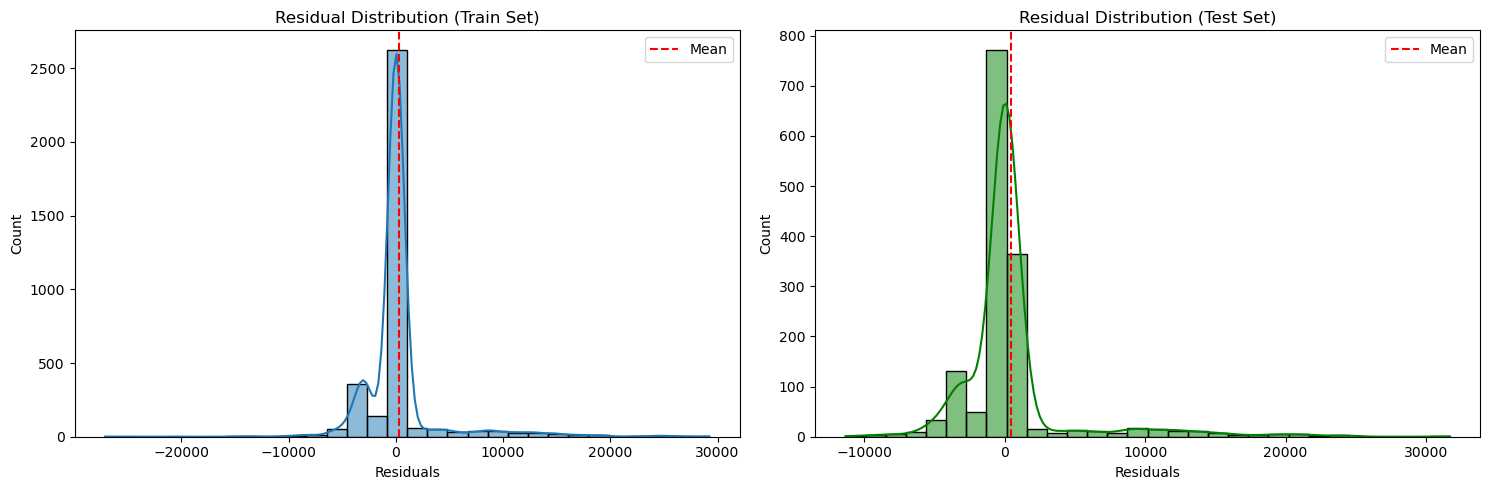

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual Distribution for training data
sns.histplot(train_residual_df['Residual'], bins=30, kde=True, ax=axes[0])
axes[0].axvline(train_residual_df['Residual'].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_title('Residual Distribution (Train Set)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Count')
axes[0].legend()

# Residual Distribution for test data
sns.histplot(residual_df['Residuals'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].axvline(residual_df['Residuals'].mean(), color='red', linestyle='--', label='Mean')
axes[1].set_title('Residual Distribution (Test Set)')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

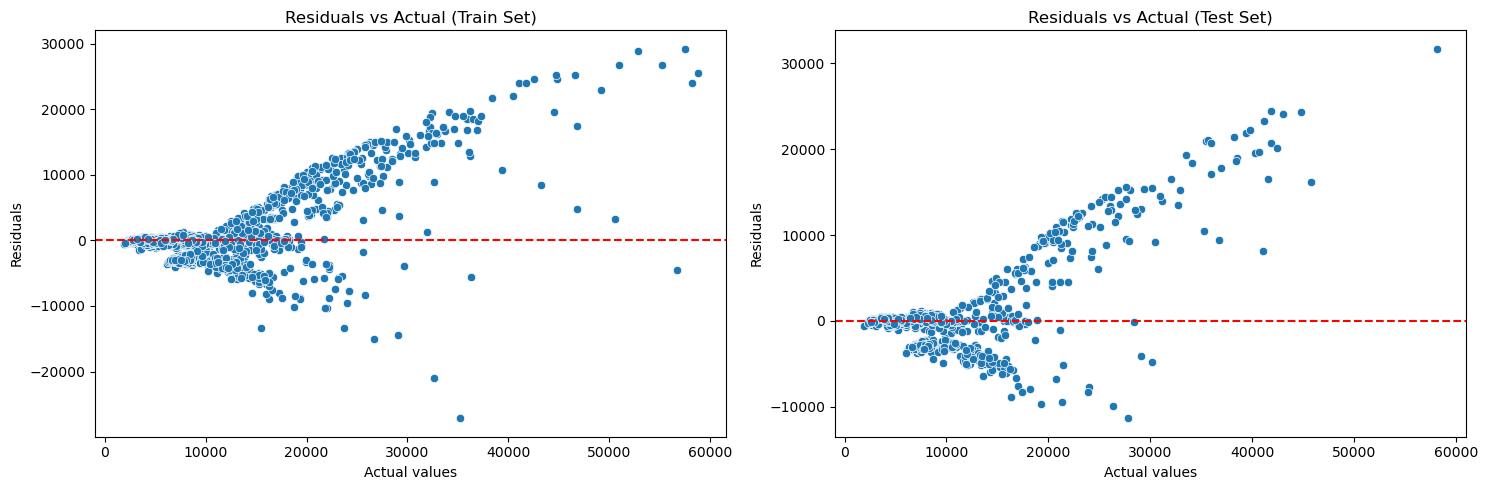

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals vs Actual plot for training data
sns.scatterplot(data=train_residual_df, x='Actual', y='Residual', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Actual (Train Set)')
axes[0].set_xlabel('Actual values')
axes[0].set_ylabel('Residuals')

# Residuals vs Actual plot for test data
sns.scatterplot(data=residual_df, x='Actual Value', y='Residuals', ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Actual (Test Set)')
axes[1].set_xlabel('Actual values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

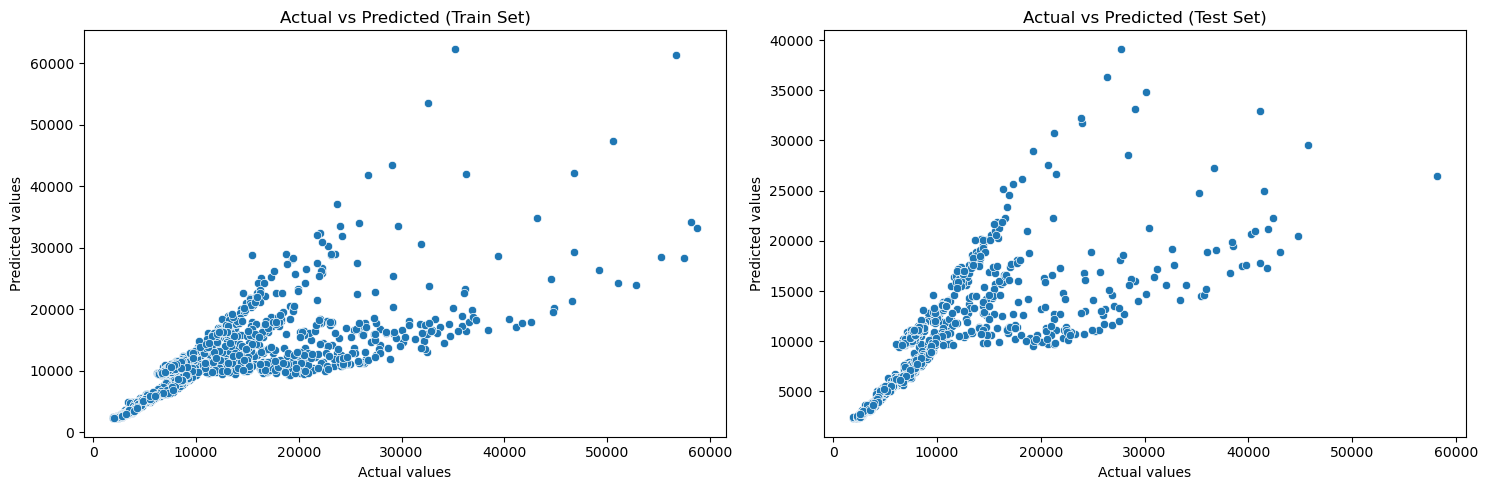

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual vs Predicted plot for training data
sns.scatterplot(data=train_residual_df, x='Actual', y='Predicted', ax=axes[0])
axes[0].set_title('Actual vs Predicted (Train Set)')
axes[0].set_xlabel('Actual values')
axes[0].set_ylabel('Predicted values')

# Actual vs Predicted plot for test data
sns.scatterplot(data=residual_df, x='Actual Value', y='Predicted Value', ax=axes[1])
axes[1].set_title('Actual vs Predicted (Test Set)')
axes[1].set_xlabel('Actual values')
axes[1].set_ylabel('Predicted values')

plt.tight_layout()
plt.show()

Observations:
- In residual distribution on both, train & test set, the mean of residuals in both train and test sets is close to zero, suggesting the model is unbiased on average. However, the long tails on both sides indicate notable overpredictions and underpredictions, meaning the model struggles with extreme values. The distributions are not bell-shaped (not normal), which violates one of the classical linear regression assumptions.
- In the test set, overpredictions appear more frequent than underpredictions, suggesting a potential upward bias when generalizing.
- In residuals and actual values comparisons, for CLV values below ~$10,000, residuals are relatively well-distributed around zero, showing stable predictions. Beyond ~$10,000, residuals become increasingly dispersed (large positive and negative errors), indicating the model’s inability to capture high-value customers accurately.
- The residual pattern suggests heteroscedasticity (residual variance increases with CLV). This confirms that linear regression’s constant variance assumption is violated, which further explains weaker performance on extreme values.
- In actual and predicted Values comparisons, the predictions on low and mid-range CLV (< $10,000) align well with actual values. For high CLV (> $10,000), predictions become unreliable — some customers are heavily underpredicted while others are strongly overpredicted. This directly explains why the model achieves ~69% R²: it fits the majority segment well but fails with rare high-value cases.
- Outliers above ~$16,600 (as flagged in EDA with IQR) are rare, meaning the model had limited training data in this range. As a result, the model cannot generalize well to these high-value customers.
- The model is reliable for “typical customers” with CLV under ~$10,000. For high-value customers, predictions are unstable. So, we should be cautious when making decisions about premium customers solely based on this model. For improvement of this model in the future, we need to collect more data from high-CLV customers. 

### Model Interpretation

**Features Importances**

In [68]:
model = lr_pipeline.named_steps['model'].regressor_
features_names = lr_pipeline.named_steps['preprocessor'].get_feature_names_out()
coef = model.coef_
coef_df = pd.DataFrame({'Feature': features_names, 'Coefficient': coef})
coef_df = coef_df.sort_values(by='Coefficient', ascending=False).reset_index(drop=True)
coef_df

,Feature,Coefficient
0,onehot__Number of Policies_2,1.401234
1,onehot__Number of Policies_9,0.698123
2,onehot__Number of Policies_4,0.696679
3,onehot__Number of Policies_8,0.696058
4,onehot__Number of Policies_3,0.693767
5,onehot__Number of Policies_6,0.693585
6,onehot__Number of Policies_7,0.691736
7,onehot__Number of Policies_5,0.690118
8,numerical__Monthly Premium Auto,0.290651
9,onehot__Vehicle Class_Sports Car,0.179282


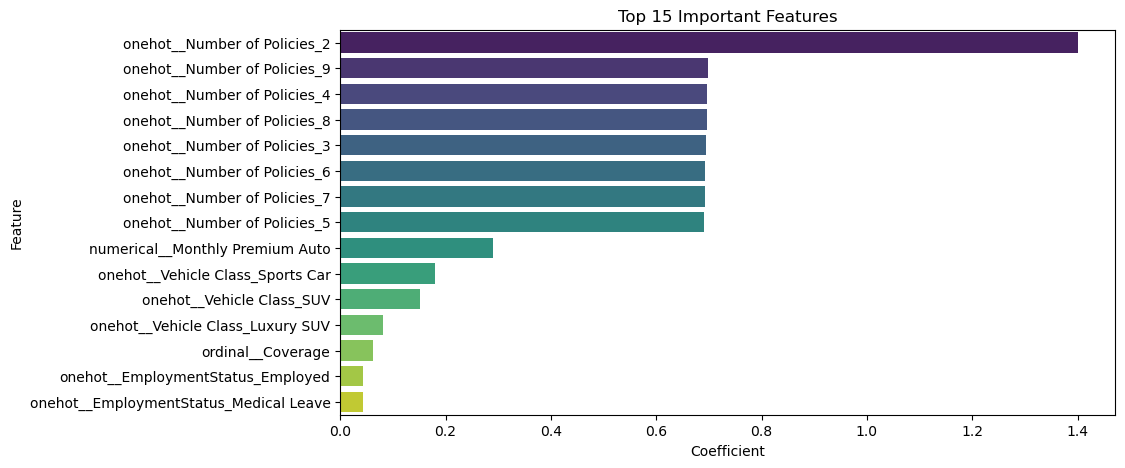

In [69]:
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df.head(15), x='Coefficient', y='Feature', palette='viridis')
plt.title('Top 15 Important Features')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()

Observations:
- The strongest predictor by far is having 2 policies, with a coefficient nearly twice as large as any other variable.
- Customers with more than 2 policies (3–9) also show consistently strong positive impacts on CLV, though the incremental gain appears to plateau. This suggests that the biggest jump in CLV occurs when a customer moves from 1 to 2 policies.
- Monthly Premium value is the most important numerical driver after policy count. Based on positive value in its coef shows that higher monthly premiums are strongly associated with higher CLV, which makes intuitive sense since CLV is partly a function of recurring payments.
- High-end vehicles, especially Sports Cars and SUVs, positively contribute to CLV. Luxury SUV and Luxury Car also add value, but their effect is smaller compared to sports cars and regular SUVs. This probably related to Monthly Premium Auto since we've known from EDA that these vehicle class tend to have high monthly premium.
- Variables like Income, Marital Status, Education, and Total Claim Amount have negligible or even negative coefficients. This suggests they don’t explain much about CLV in this dataset and could be de-prioritized in marketing strategies.

**SHAP**

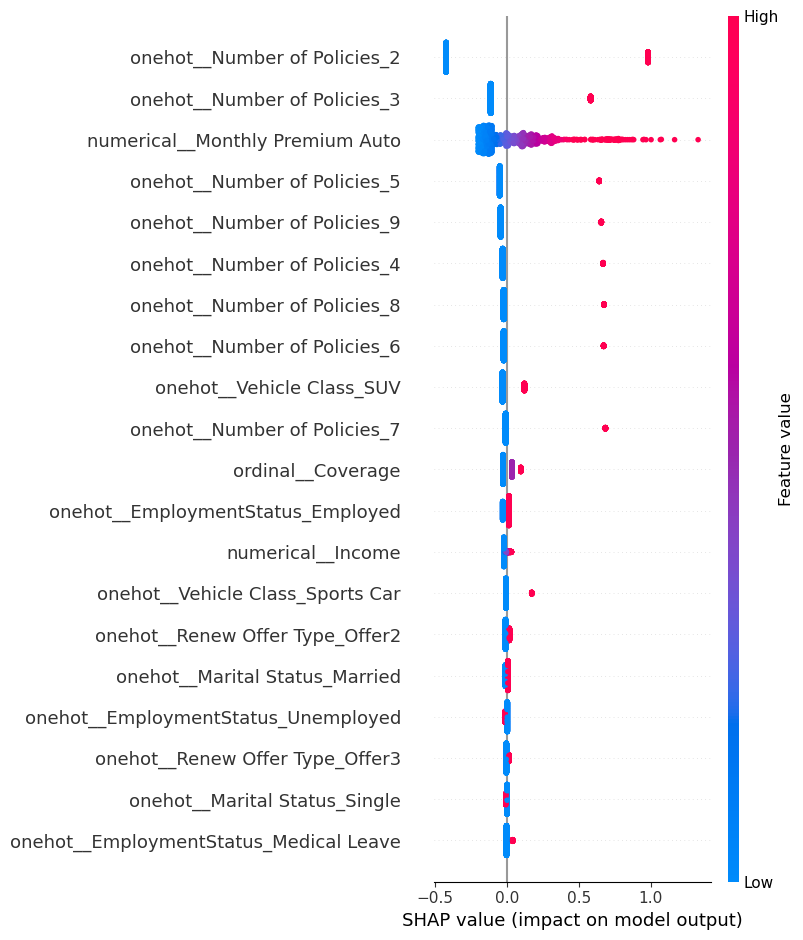

In [70]:
# Extract preprocessed steps on pipeline
X_preprocessed = lr_pipeline.named_steps['preprocessor'].transform(X_test)

# Using SHAP to explain the model
explainer = shap.Explainer(model, X_preprocessed)
shap_values = explainer(X_preprocessed)
shap.summary_plot(shap_values, X_preprocessed, feature_names=features_names)

Observations:
- SHAP confirms that having 2 policies provides the largest positive boost to CLV, stronger than any other feature. Customers with only 1 policy are consistently low CLV, while having more than 2 policies also raises CLV but less dramatically than the jump from 1 policy to 2 policies.
- Higher premiums push CLV upward, while lower premiums reduce it. This aligns with coefficient results, reinforcing premium size as a reliable lever for CLV growth.
- Coefficients suggested Sports Cars had the largest effect among vehicle types. SHAP, however, indicates that SUV owners contribute more consistently to higher CLV than Sports Car owners. This suggests that while Sports Cars are rare but high-value (spikes in coefficients), SUVs are a broader, more stable contributor to CLV across many customers.
- Coefficients suggested that being on Medical Leave on Employement Status has the largest effect. SHAP shows that being Employed is a stronger and more consistent predictor of higher CLV. This difference arises because coefficients capture average linear effects, while SHAP highlights how features behave across all customers. Medical Leave may affect only a few high-CLV customers (inflating coefficients), while Employment status consistently affects many.

**Model Intepretability Conclusion**
- Customers with 2 policies show the largest increase in CLV compared to those with only 1 policy. Having more than 2 policies continues to raise CLV but with diminishing impact. So, Cross-selling from 1 to 2 policies should be a primary strategy, with targeted offers to encourage additional policy adoption. For customers with more than 2 policies, we could offerin to simplify their policies closer to 2 policies may deliver better long-term CLV growth than continuing to add individual policies.
- Higher premiums lead to higher CLV across the board. So, we could optimizing premium levels (e.g., through upsell to extended coverage or higher-value policies) directly strengthens CLV or accept more new customers with niche luxury segments vehicle class which are SUV, Sports Car, Luxury SUV, and Luxury Cars. Coefficients emphasize Sports Cars as the most impactful. SHAP, however, shows SUVs contribute more consistently to higher CLV across the customer base. But, these four vehicle class show as parts of top 15 importance features based on coef
- Coefficients highlight Medical Leave as highly impactful, likely due to a small group of outlier customers. SHAP reveals that being Employed is a stronger and more consistent predictor of higher CLV. So, targeting employed customers as a reliable high-CLV base may yield more sustainable long-term results than focusing on rare categories.

**Individual Data SHAP Explained**

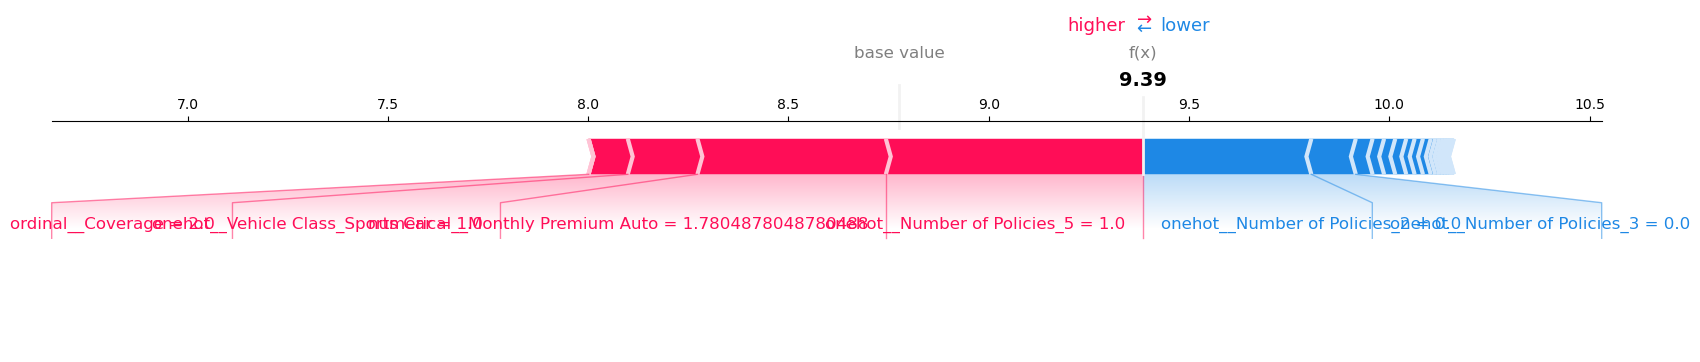

In [71]:
shap.plots.force(
    explainer.expected_value,
    shap_values[12].values,
    X_preprocessed[12],
    feature_names=lr_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    matplotlib=True,
    show=False
)

Observations of SHAP Force Plot on Index 12:
- Prediction = 9.38
- Base value = ~8.8, so the model predicted more than average CLV (log-transformed).
- Features that increase this customer’s predicted CLV compared to the average for index 12 are Coverage (higher coverage category) pushes CLV up, Vehicle Class Sports Car that associated with higher CLV, Monthly Premium Auto ≈$188 that relatively high premium so it increases CLV and 5 number of policies that also pushes CLV upward.
- Features that decrease CLV compared to the average for index 12 are not having 2 policies strongly drags the prediction downward and not having 3 policies also slightly pulls it down.

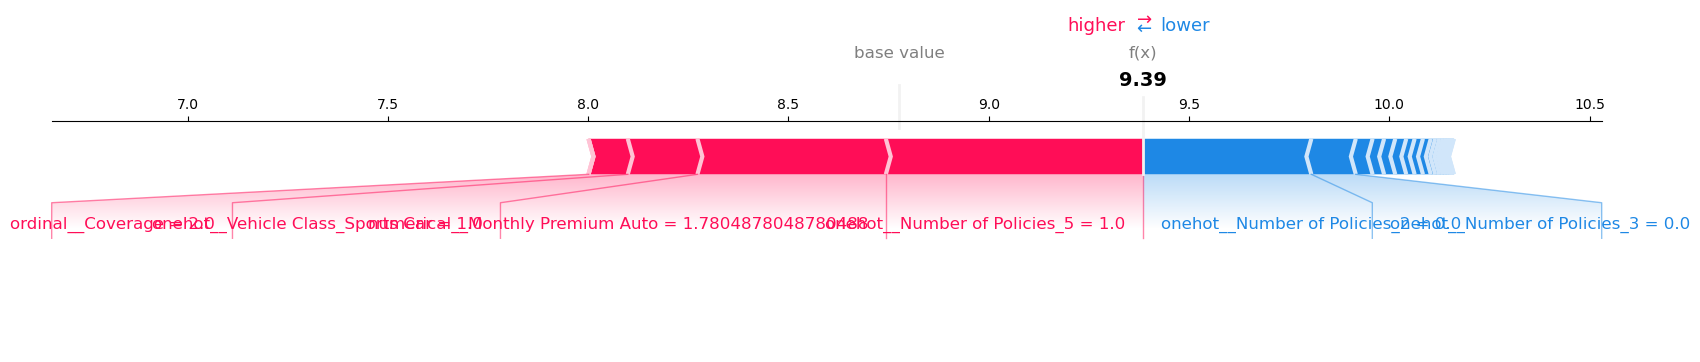

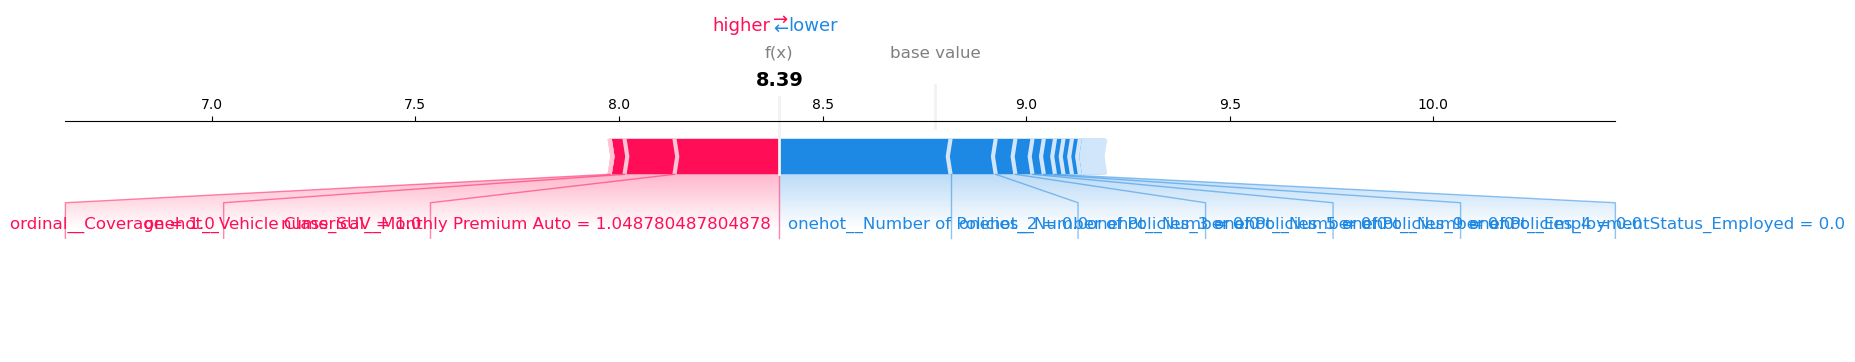

In [72]:
shap.plots.force(
    explainer.expected_value,
    shap_values[47].values,
    X_preprocessed[47],
    feature_names=lr_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    matplotlib=True
)

Observations of SHAP Force Plot on Index 47:
- Prediction = 8.39
- Base value = ~8.8, so the model predicted lower than average CLV (log-transformed).
- Features that increase this customer’s predicted CLV compared to the average for index 47 are Coverage Basic, Vehicle Class Sports Car, Monthly Premium Auto (scaled = 1.075) that is above-average premium (in scaled units)
- Features that decrease CLV compared to the average for index 47 are having 1 policy (shows by 0.0 value of many policy combination)

### Post Model Analytic : Predicted CLV > $10,000
The model performs well when the predicted Customer Lifetime Value (CLV) is around or below $10,000. However, when the predicted CLV exceeds $10,000, the model appears to be less reliable. To better understand this behavior, we will analyze the characteristics of the data points with predicted CLV values above and below the $10,000 threshold in test dataset. This comparison will help identify potential gaps in the model and provide insights for improving its reliability in future iterations.

In [73]:
# Prediction dataframe
prediction_df = X_test.copy()
prediction_df['Customer Lifetime Value Prediction'] = y_pred_lr
prediction_df.reset_index(drop=True, inplace=True)

# Predicted Customer Lifetime Value >10000
high_pred = prediction_df[prediction_df['Customer Lifetime Value Prediction']>10000]

# Predicted Customer Lifetime Value <= 10000
low_pred = prediction_df[prediction_df['Customer Lifetime Value Prediction']<=10000]

In [74]:
print(f'There are {high_pred.shape[0]} customers who predicted to have Customer Lifetime Value > $10,000 or about {round(high_pred.shape[0]/prediction_df.shape[0]*100, 2)}% of total customers in the test set.')

There are 430 customers who predicted to have Customer Lifetime Value > $10,000 or about 28.4% of total customers in the test set.


In [75]:
high_pred.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Vehicle Class,430,6,Four-Door Car,179,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coverage,430,3,Basic,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renew Offer Type,430,4,Offer1,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmploymentStatus,430,5,Employed,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital Status,430,3,Married,267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,430,5,Bachelor,128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Policies,430.0,9.0,2.0,371.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Premium Auto,430.0,NaN,NaN,NaN,104.139535,42.064099,61.0,71.0,93.5,124.0,276.0
Total Claim Amount,430.0,NaN,NaN,NaN,462.162237,329.621733,2.574682,231.404787,373.284743,618.972212,2027.724442
Income,430.0,NaN,NaN,NaN,42745.804651,29930.841853,0.0,21004.75,40702.5,65995.25,99875.0


In [76]:
low_pred.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Vehicle Class,1084,6,Four-Door Car,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Coverage,1084,3,Basic,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Renew Offer Type,1084,4,Offer1,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmploymentStatus,1084,5,Employed,624,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital Status,1084,3,Married,614,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1084,5,Bachelor,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Policies,1084.0,9.0,1.0,517.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly Premium Auto,1084.0,NaN,NaN,NaN,87.601476,25.769771,61.0,68.0,78.0,104.0,199.0
Total Claim Amount,1084.0,NaN,NaN,NaN,424.251137,270.313018,2.54009,277.892323,379.2,541.807706,2327.166394
Income,1084.0,NaN,NaN,NaN,35320.685424,31561.502767,0.0,0.0,30370.0,61389.25,99841.0


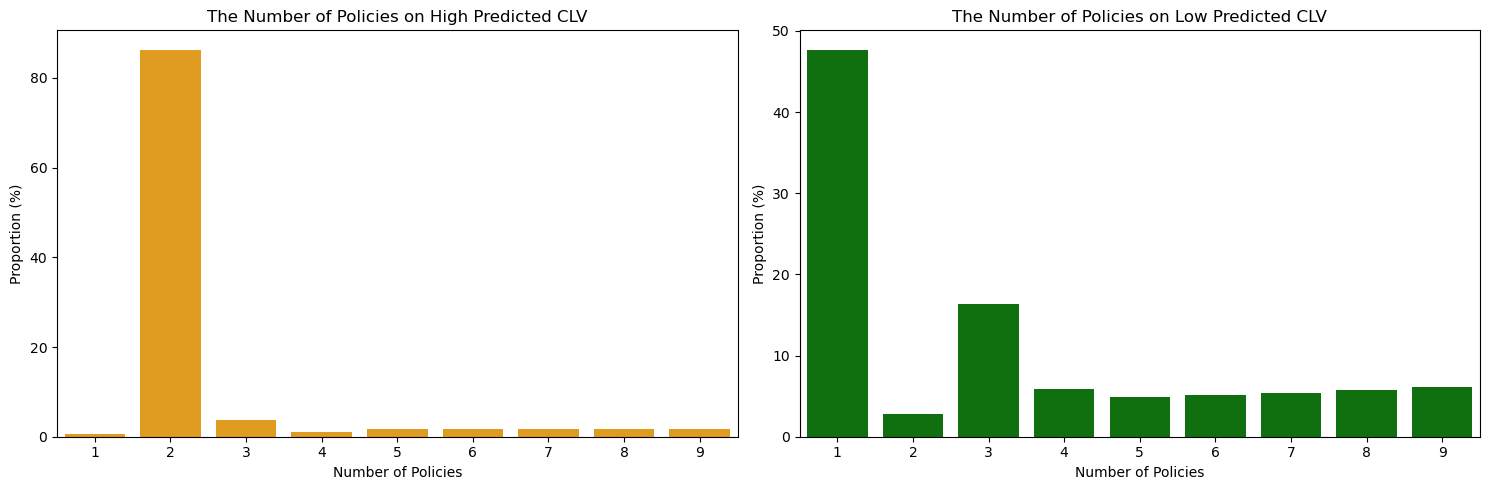

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram for high predicted CLV
sns.countplot(data=high_pred, x='Number of Policies', ax=axes[0], stat='percent', color='orange')
axes[0].set_title('The Number of Policies on High Predicted CLV')
axes[0].set_xlabel('Number of Policies')
axes[0].set_ylabel('Proportion (%)')

# Histogram for low predicted CLV
sns.countplot(data=low_pred, x='Number of Policies', ax=axes[1], stat='percent', color='green')
axes[1].set_title('The Number of Policies on Low Predicted CLV')
axes[1].set_xlabel('Number of Policies')
axes[1].set_ylabel('Proportion (%)')

plt.tight_layout()
plt.show()

Observations:
- The differences between these two are :
    - Customers who predicted with CLV >$10,000 tend to have 2 policies (most frequent). While, customers who predicted with CLV <=$10,000 mostly hold only 1 policy, then following with 3 policies.
    - The highest Monthly Premium Auto is $276 for those predicted to have CLV >$10,000. For customers with CLV <=$10,000, the highest Monthly Premium Auto is $199.
- These differences align with our insight of features that influencial to CLV in EDA and SHAP explainer. The higher CLV customers seem to have a more extensive relationship with the insurance company when holding 2 policies, not less or more, and higher premium payments that leading to higher lifetime value.

## Conclusion & Recommendation

In [81]:
model_evaluation

,Dataset,RMSE Lin,RMSE Ridge,MAE Lin,MAE Ridge,MAPE Lin,MAPE Ridge,R2 Lin,R2 Ridge
0,Train,3678.079858,3681.114162,1553.182408,1552.934463,0.116160,0.116026,0.690926,0.690416
1,Test,4048.018877,4051.714073,1729.669315,1729.281834,12.198369,12.184990,0.657990,0.657365


### Conclusion
- The best-performing model in this project is Linear Regression, achieving an RMSE of $4,048, MAE of $1,729, MAPE of 12%, and an R² of approximately 0.65. While the model demonstrates reasonable performance, it explains only about 65% of the variance, suggesting that there is still room for improvement. The model struggles to capture patterns in the outliers or the high CLV (Customer Lifetime Value) segment due to the limited data available for those cases. The linearity observed for lower predicted CLV values breaks down at higher predicted CLV, where the model fails to capture the expected pattern.
- Residual analysis shows that for lower predicted values (up to $10,000), the residuals are clustered around zero, indicating that the model’s predictions are fairly accurate. However, for higher predictions (more than $10,000), the residuals become more dispersed, with most being positive (underprediction), which suggests that the model tends to underestimate the real CLV values. To improve this, it is recommended that the company focus on gathering more data from high-CLV customers to better train the model in this segment.
- In terms of feature importance, the "Number of Policies" is the most influential predictor, followed by "Monthly Premium Auto." Interestingly, the highest CLV values are associated with customers who hold a maximum of two policies, despite expectations that a higher number of policies would correlate with higher CLV. This suggests that while holding more policies may lead to higher premiums, it doesn’t necessarily translate into higher CLV, possibly due to diminishing returns with additional policies. Additionally, the coefficient and SHAP explainer show that the "Number of Policies" has a higher influence on CLV than "Monthly Premium Auto." Therefore, it is recommended that the company prioritize strategies that encourage customers to hold no more than two policies.
- From the EDA, we also observed that "Monthly Premium Auto" correlates with vehicle class (SUV, Sport Car, and Luxury SUV) and coverage type (Premium). This relationship explains why these features appear among the top 15 in both the coefficient and SHAP explainer.
- Finally, while global feature importance provides insight into general trends, individual predictions may differ. SHAP values highlight that the key drivers of CLV can vary significantly by customer, underscoring the importance of personalized analysis when developing customer strategies.

### **Recommendation for Existing Customer:**
1. Encourage Cross-Selling for Customers with One Policy by cross-selling campaigns so they would added one more policy
2. For customers already holding three or more policies, the emphasis should be on simplify their policies by bundling or offering higher coverage or increasing their Monthly Premium Auto and consolidating them into two policies. This strategy targets customers whose CLV does not increase significantly with more policies but may be more satisfied with a simplified policy set.
3. Encourage customers to upgrade their Monthly Premium Auto to at least $100 (the mean of high CLV values). SHAP analysis shows that higher monthly premiums correlate strongly with CLV, and many top-performing customers already pay at or above this amount. Offering tailored premiums based on customer segments (e.g., SUV owners, employed individuals) could further boost CLV.

**Recommendation for New Customer:**
1. Focus acquisition efforts on segments with characteristics predictive of higher CLV. This includes SUV and Luxury car owners Vehicle Class, candidate customer who willing to choose Extended or Premium Coverage, focus on middle to upper-income individuals, especially married and employed or unemployed customers, candidate customers who willing to commit to a Monthly Premium Auto of $100 or more, customers who are willing to hold at least two policies. 
2. Create tailored bundles for customers who own SUVs or luxury vehicles, offering premium or extended coverage that appeals to this segment. This will align with the strategic implication of growing the customer base in these higher-value segments.


# Save The Model

In [78]:
# Save the model
pickle.dump(lr_pipeline, open('CLV_prediction_model.sav', 'wb'))

In [79]:
# Load the model
loaded_model = pickle.load(open('CLV_prediction_model.sav', 'rb'))

In [80]:
root_mean_squared_error(y_test, loaded_model.predict(X_test))

4048.018876715177